
## **📓 NOTEBOOK 1**
**COLLECTE ET EXPLORATION DES PLAINTES CLIENTS**


# 🤖 Copilote d'Intelligence sur les Plaintes Clients

## Notebook 1 — Collecte et Exploration des données

### Domaine
Finance et Risque

### Dataset
CFPB Consumer Complaint Database

### Volume de travail
50 000 plaintes clients

### Objectif général

L'objectif de ce projet est de développer un copilote intelligent capable
d'analyser les plaintes des consommateurs dans le secteur financier.

Le système combinera plusieurs techniques d'intelligence artificielle :

- NLP supervisé pour la classification des plaintes ;
- clustering non supervisé pour découvrir les thèmes émergents ;
- embeddings pour représenter les plaintes sémantiquement ;
- détection d'anomalies pour identifier les comportements inhabituels ;
- RAG pour permettre au copilote de rechercher et synthétiser les informations pertinentes.

Ce premier notebook est consacré à la préparation et à l'exploration
du jeu de données.

**1. Installation des bibliothèques**

In [ ]:
!pip install requests pandas numpy matplotlib seaborn

**2. Importation des bibliothèques**

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time

**3. Configuration du projet**

In [ ]:
# Nombre de plaintes souhaité pour notre échantillon final
TARGET_SIZE = 100_000

# Nombre de plaintes récupérées par requête
BATCH_SIZE = 1000

# URL de l'API CFPB
API_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

In [ ]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

**4. Testons l'API avec 10 plaintes**

In [ ]:
params = {
    "size": 10,
    "from": 0
}

response = requests.get(API_URL, params=params, headers=HEADERS)

print("Code HTTP :", response.status_code)

Code HTTP : 200


**5-Lisons la réponse JSON**

In [ ]:
data = response.json()

print(type(data))

<class 'dict'>


In [ ]:
print(data.keys())

dict_keys(['took', 'timed_out', '_shards', 'hits', 'aggregations', '_meta'])


**6-Vérifions le nombre total de plaintes**

In [ ]:
total_complaints = data["hits"]["total"]["value"]

print(
    "Nombre total de plaintes disponibles :",
    total_complaints
)

Nombre total de plaintes disponibles : 16639404


**7-Examinons une plainte**

In [ ]:
first_complaint = data["hits"]["hits"][0]["_source"]

print(
    json.dumps(
        first_complaint,
        indent=4,
        ensure_ascii=False
    )
)

{
    "product": "Credit reporting or other personal consumer reports",
    "complaint_what_happened": "",
    "date_sent_to_company": "2024-09-03T22:42:56.000Z",
    "issue": "Improper use of your report",
    "sub_product": "Credit reporting",
    "zip_code": "33060",
    "tags": null,
    "has_narrative": false,
    "complaint_id": "9999997",
    "timely": "Yes",
    "company_response": "Closed with non-monetary relief",
    "submitted_via": "Web",
    "company": "TRANSUNION INTERMEDIATE HOLDINGS, INC.",
    "date_received": "2024-09-03T22:42:53.000Z",
    "state": "FL",
    "company_public_response": "Company has responded to the consumer and the CFPB and chooses not to provide a public response",
    "sub_issue": "Reporting company used your report improperly"
}


**8-Extraire les plaintes**

In [ ]:
def extract_complaints(data):

    complaints = []

    hits = data.get(
        "hits",
        {}
    ).get(
        "hits",
        []
    )

    for hit in hits:

        source = hit.get(
            "_source",
            {}
        )

        complaints.append(source)

    return complaints

**9-Testons avec 10 plaintes**

In [ ]:
complaints_test = extract_complaints(data)

print(
    "Nombre de plaintes récupérées :",
    len(complaints_test)
)

Nombre de plaintes récupérées : 10


**10-Convertissons en DataFrame**

In [ ]:
df_test = pd.DataFrame(
    complaints_test
)

df_test.head()

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999997,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2024-09-03T22:42:53.000Z,FL,Company has responded to the consumer and the ...,Reporting company used your report improperly
1,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999996,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:42:53.000Z,FL,None,Reporting company used your report improperly
2,Credit reporting or other personal consumer re...,,2024-09-03T22:52:19.000Z,Problem with a company's investigation into an...,Credit reporting,89014,None,False,9999995,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:41:36.000Z,NV,None,Their investigation did not fix an error on yo...
3,Credit reporting or other personal consumer re...,,2024-09-03T22:39:41.000Z,Improper use of your report,Credit reporting,99224,None,False,9999994,Yes,Closed with explanation,Web,"EQUIFAX, INC.",2024-09-03T22:37:10.000Z,WA,None,Credit inquiries on your report that you don't...
4,Credit reporting or other personal consumer re...,,2024-09-03T22:24:21.000Z,Incorrect information on your report,Credit reporting,30349,None,False,9999989,Yes,Closed with explanation,Web,Lendmark Financial Services,2024-09-03T22:22:09.000Z,GA,None,Information belongs to someone else


**11-Affichons les colonnes**

In [ ]:
print(
    df_test.columns.tolist()
)

['product', 'complaint_what_happened', 'date_sent_to_company', 'issue', 'sub_product', 'zip_code', 'tags', 'has_narrative', 'complaint_id', 'timely', 'company_response', 'submitted_via', 'company', 'date_received', 'state', 'company_public_response', 'sub_issue']


In [ ]:
for start in range(0, 100000, 1000):

    params = {
        "size": 1000,
        "from": start
    }

In [ ]:
print(df_test.columns.tolist())

['product', 'complaint_what_happened', 'date_sent_to_company', 'issue', 'sub_product', 'zip_code', 'tags', 'has_narrative', 'complaint_id', 'timely', 'company_response', 'submitted_via', 'company', 'date_received', 'state', 'company_public_response', 'sub_issue']


**12-Vérifions la structure du DataFrame**

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   product                  10 non-null     object
 1   complaint_what_happened  10 non-null     object
 2   date_sent_to_company     10 non-null     object
 3   issue                    10 non-null     object
 4   sub_product              10 non-null     object
 5   zip_code                 10 non-null     object
 6   tags                     0 non-null      object
 7   has_narrative            10 non-null     bool  
 8   complaint_id             10 non-null     object
 9   timely                   10 non-null     object
 10  company_response         10 non-null     object
 11  submitted_via            10 non-null     object
 12  company                  10 non-null     object
 13  date_received            10 non-null     object
 14  state                    10 non-null     obje

In [ ]:
print("Nombre de lignes :", df_test.shape[0])
print("Nombre de colonnes :", df_test.shape[1])

Nombre de lignes : 10
Nombre de colonnes : 17


**13-Affichons un aperçu complet**

In [ ]:
pd.set_option(
    "display.max_columns",
    None
)

df_test.head()

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999997,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2024-09-03T22:42:53.000Z,FL,Company has responded to the consumer and the ...,Reporting company used your report improperly
1,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999996,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:42:53.000Z,FL,None,Reporting company used your report improperly
2,Credit reporting or other personal consumer re...,,2024-09-03T22:52:19.000Z,Problem with a company's investigation into an...,Credit reporting,89014,None,False,9999995,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:41:36.000Z,NV,None,Their investigation did not fix an error on yo...
3,Credit reporting or other personal consumer re...,,2024-09-03T22:39:41.000Z,Improper use of your report,Credit reporting,99224,None,False,9999994,Yes,Closed with explanation,Web,"EQUIFAX, INC.",2024-09-03T22:37:10.000Z,WA,None,Credit inquiries on your report that you don't...
4,Credit reporting or other personal consumer re...,,2024-09-03T22:24:21.000Z,Incorrect information on your report,Credit reporting,30349,None,False,9999989,Yes,Closed with explanation,Web,Lendmark Financial Services,2024-09-03T22:22:09.000Z,GA,None,Information belongs to someone else


**14-Vérifions les valeurs manquantes**

In [ ]:
missing_values = df_test.isnull().sum()

print(
    missing_values
)

product                     0
complaint_what_happened     0
date_sent_to_company        0
issue                       0
sub_product                 0
zip_code                    0
tags                       10
has_narrative               0
complaint_id                0
timely                      0
company_response            0
submitted_via               0
company                     0
date_received               0
state                       0
company_public_response     7
sub_issue                   0
dtype: int64


In [ ]:
missing_percentage = (
    df_test.isnull().mean() * 100
).sort_values(
    ascending=False
)

print(
    missing_percentage
)

tags                       100.0
company_public_response     70.0
product                      0.0
issue                        0.0
complaint_what_happened      0.0
sub_product                  0.0
zip_code                     0.0
has_narrative                0.0
date_sent_to_company         0.0
complaint_id                 0.0
timely                       0.0
submitted_via                0.0
company_response             0.0
company                      0.0
date_received                0.0
state                        0.0
sub_issue                    0.0
dtype: float64


**15-Vérifions les doublons**

In [ ]:
print(
    "Nombre de complaint_id uniques :",
    df_test["complaint_id"].nunique()
)

Nombre de complaint_id uniques : 10


In [ ]:
print(
    "Nombre total de plaintes :",
    len(df_test)
)

Nombre total de plaintes : 10


In [ ]:
print(
    "Nombre de doublons sur complaint_id :",
    df_test["complaint_id"].duplicated().sum()
)

Nombre de doublons sur complaint_id : 0


**16-Vérifions les récits clients**

In [ ]:
print(
    df_test["has_narrative"].value_counts(
        dropna=False
    )
)

has_narrative
False    9
True     1
Name: count, dtype: int64


In [ ]:
print(
    "Nombre de plaintes avec récit :",
    df_test["has_narrative"].sum()
)

Nombre de plaintes avec récit : 1


In [ ]:
print(
    "Pourcentage de plaintes avec récit :",
    round(
        df_test["has_narrative"].mean() * 100,
        2
    ),
    "%"
)

Pourcentage de plaintes avec récit : 10.0 %


**17-Vérifions le texte des plaintes**

In [ ]:
df_test[
    [
        "complaint_id",
        "product",
        "issue",
        "complaint_what_happened"
    ]
].head(10)

,complaint_id,product,issue,complaint_what_happened
0,9999997,Credit reporting or other personal consumer re...,Improper use of your report,
1,9999996,Credit reporting or other personal consumer re...,Improper use of your report,
2,9999995,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,
3,9999994,Credit reporting or other personal consumer re...,Improper use of your report,
4,9999989,Credit reporting or other personal consumer re...,Incorrect information on your report,
5,9999988,Credit reporting or other personal consumer re...,Incorrect information on your report,
6,9999986,Credit reporting or other personal consumer re...,Improper use of your report,
7,9999985,Credit reporting or other personal consumer re...,Incorrect information on your report,
8,9999984,Credit reporting or other personal consumer re...,Incorrect information on your report,
9,9999983,Credit card,Getting a credit card,Chae bank called me about a fraudulent case ap...


In [ ]:
df_test["text_length"] = (
    df_test["complaint_what_happened"]
    .fillna("")
    .str.len()
)

In [ ]:
df_test["text_length"].describe()

,text_length
count,10.000000
mean,21.700000
std,68.621425
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,217.000000


**18-Vérifions les produits financiers**

In [ ]:
print(
    df_test["product"].value_counts()
)

product
Credit reporting or other personal consumer reports    9
Credit card                                            1
Name: count, dtype: int64


In [ ]:
df_test[
    "product"
].value_counts().head(10)

,count
product,
Credit reporting or other personal consumer reports,9
Credit card,1


**19-Vérifions les problèmes**

In [ ]:
print(
    df_test["issue"].value_counts().head(20)
)

issue
Improper use of your report                                        4
Incorrect information on your report                               4
Problem with a company's investigation into an existing problem    1
Getting a credit card                                              1
Name: count, dtype: int64


**20-Vérifions les sous-problèmes**

In [ ]:
print(
    df_test["sub_issue"].value_counts().head(20)
)

sub_issue
Information belongs to someone else                         4
Reporting company used your report improperly               2
Credit inquiries on your report that you don't recognize    2
Their investigation did not fix an error on your report     1
Card opened without my consent or knowledge                 1
Name: count, dtype: int64


**21-Vérifions les entreprises**

In [ ]:
print(
    df_test["company"].value_counts().head(20)
)

company
EQUIFAX, INC.                             5
TRANSUNION INTERMEDIATE HOLDINGS, INC.    2
Lendmark Financial Services               1
Experian Information Solutions Inc.       1
JPMORGAN CHASE & CO.                      1
Name: count, dtype: int64


**22-Vérifions les canaux de soumission**

In [ ]:
print(
    df_test["submitted_via"].value_counts()
)

submitted_via
Web    10
Name: count, dtype: int64


**23-Vérifions les réponses des entreprises**

In [ ]:
print(
    df_test["company_response"].value_counts()
)

company_response
Closed with non-monetary relief    6
Closed with explanation            4
Name: count, dtype: int64


**24-Vérifions la variable timely**

In [ ]:
print(
    df_test["timely"].value_counts()
)

timely
Yes    10
Name: count, dtype: int64


**25-Convertissons les dates**

In [ ]:
df_test["date_received"] = pd.to_datetime(
    df_test["date_received"],
    errors="coerce"
)

df_test["date_sent_to_company"] = pd.to_datetime(
    df_test["date_sent_to_company"],
    errors="coerce"
)

In [ ]:
print(
    df_test[
        [
            "date_received",
            "date_sent_to_company"
        ]
    ].dtypes
)

date_received           datetime64[ns, UTC]
date_sent_to_company    datetime64[ns, UTC]
dtype: object


**26-Créons les variables temporelles**

In [ ]:
df_test["year"] = (
    df_test["date_received"].dt.year
)

df_test["month"] = (
    df_test["date_received"].dt.month
)

df_test["quarter"] = (
    df_test["date_received"].dt.quarter
)

**27-Vérifions la période couverte**

In [ ]:
print(
    "Date minimale :",
    df_test["date_received"].min()
)

print(
    "Date maximale :",
    df_test["date_received"].max()
)

Date minimale : 2024-09-03 21:46:19+00:00
Date maximale : 2024-09-03 22:45:03+00:00


**28-Préparons la collecte principale**

In [ ]:
def collect_complaints(
    target_size=1000,
    batch_size=100
):

    all_complaints = []

    for start in range(
        0,
        target_size,
        batch_size
    ):

        params = {
            "size": batch_size,
            "from": start
        }

        print(
            f"Collecte des plaintes "
            f"{start} à {start + batch_size}"
        )

        response = requests.get(
            API_URL,
            params=params,
            headers=HEADERS,
            timeout=60
        )

        response.raise_for_status()

        data = response.json()

        complaints = extract_complaints(
            data
        )

        all_complaints.extend(
            complaints
        )

        print(
            "Total collecté :",
            len(all_complaints)
        )

        time.sleep(1)

    return pd.DataFrame(
        all_complaints
    )

**29-Collectons 1 000 plaintes**

In [ ]:
df = collect_complaints(
    target_size=1000,
    batch_size=100
)

Collecte des plaintes 0 à 100
Total collecté : 100
Collecte des plaintes 100 à 200
Total collecté : 200
Collecte des plaintes 200 à 300
Total collecté : 300
Collecte des plaintes 300 à 400
Total collecté : 400
Collecte des plaintes 400 à 500
Total collecté : 500
Collecte des plaintes 500 à 600
Total collecté : 600
Collecte des plaintes 600 à 700
Total collecté : 700
Collecte des plaintes 700 à 800
Total collecté : 800
Collecte des plaintes 800 à 900
Total collecté : 900
Collecte des plaintes 900 à 1000
Total collecté : 1000


In [ ]:
print(
    "Dimensions :",
    df.shape
)

Dimensions : (1000, 17)


**30-Sauvegardons en CSV**

In [ ]:
os.makedirs(
    "data/raw",
    exist_ok=True
)

In [ ]:
df.to_csv(
    "data/raw/complaints_raw_1000.csv",
    index=False,
    encoding="utf-8-sig"
)

**31-Vérifions le fichier**

In [ ]:
print(
    os.path.exists(
        "data/raw/complaints_raw_1000.csv"
    )
)

True


In [ ]:
df = collect_complaints(
    target_size=1000,
    batch_size=100
)

print("Dimensions :", df.shape)

Collecte des plaintes 0 à 100
Total collecté : 100
Collecte des plaintes 100 à 200
Total collecté : 200
Collecte des plaintes 200 à 300
Total collecté : 300
Collecte des plaintes 300 à 400
Total collecté : 400
Collecte des plaintes 400 à 500
Total collecté : 500
Collecte des plaintes 500 à 600
Total collecté : 600
Collecte des plaintes 600 à 700
Total collecté : 700
Collecte des plaintes 700 à 800
Total collecté : 800
Collecte des plaintes 800 à 900
Total collecté : 900
Collecte des plaintes 900 à 1000
Total collecté : 1000
Dimensions : (1000, 17)


In [ ]:
df.head()

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999997,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2024-09-03T22:42:53.000Z,FL,Company has responded to the consumer and the ...,Reporting company used your report improperly
1,Credit reporting or other personal consumer re...,,2024-09-03T22:42:56.000Z,Improper use of your report,Credit reporting,33060,None,False,9999996,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:42:53.000Z,FL,None,Reporting company used your report improperly
2,Credit reporting or other personal consumer re...,,2024-09-03T22:52:19.000Z,Problem with a company's investigation into an...,Credit reporting,89014,None,False,9999995,Yes,Closed with non-monetary relief,Web,"EQUIFAX, INC.",2024-09-03T22:41:36.000Z,NV,None,Their investigation did not fix an error on yo...
3,Credit reporting or other personal consumer re...,,2024-09-03T22:39:41.000Z,Improper use of your report,Credit reporting,99224,None,False,9999994,Yes,Closed with explanation,Web,"EQUIFAX, INC.",2024-09-03T22:37:10.000Z,WA,None,Credit inquiries on your report that you don't...
4,Credit reporting or other personal consumer re...,,2024-09-03T22:24:21.000Z,Incorrect information on your report,Credit reporting,30349,None,False,9999989,Yes,Closed with explanation,Web,Lendmark Financial Services,2024-09-03T22:22:09.000Z,GA,None,Information belongs to someone else


**32-Vérifions les dimensions**

In [ ]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 1000
Nombre de colonnes : 17


**33-Vérifions les doublons**

In [ ]:
print(
    "Nombre de doublons sur complaint_id :",
    df["complaint_id"].duplicated().sum()
)

Nombre de doublons sur complaint_id : 900


**34-Vérifions les récits disponibles**

In [ ]:
print(
    df["has_narrative"].value_counts(
        dropna=False
    )
)

has_narrative
False    830
True     170
Name: count, dtype: int64


In [ ]:
narrative_percentage = (
    df["has_narrative"].mean() * 100
)

print(
    f"Pourcentage de plaintes avec récit : "
    f"{narrative_percentage:.2f}%"
)

Pourcentage de plaintes avec récit : 17.00%


**35-Calculons la longueur des plaintes**

In [ ]:
df["text_length"] = (
    df["complaint_what_happened"]
    .fillna("")
    .str.len()
)

In [ ]:
df["text_length"].describe()

,text_length
count,1000.00000
mean,92.93000
std,302.75086
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,2362.00000


In [ ]:
print(
    "Longueur moyenne des plaintes :",
    round(
        df["text_length"].mean(),
        2
    )
)

Longueur moyenne des plaintes : 92.93


**36-Vérifions les textes vides**

In [ ]:
empty_texts = (
    df["complaint_what_happened"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Nombre de plaintes sans texte :",
    empty_texts
)

Nombre de plaintes sans texte : 830


**37-Analysons des produits**

In [ ]:
product_distribution = (
    df["product"]
    .value_counts()
)

print(
    product_distribution
)

product
Credit reporting or other personal consumer reports    900
Debt collection                                         60
Credit card                                             30
Bank account or service                                 10
Name: count, dtype: int64


**38-Analyse des problèmes**

In [ ]:
issue_distribution = (
    df["issue"]
    .value_counts()
)

print(
    issue_distribution.head(20)
)

issue
Incorrect information on your report                               520
Improper use of your report                                        200
Problem with a company's investigation into an existing problem    190
Attempts to collect debt not owed                                   30
Written notification about debt                                     30
Getting a credit card                                               10
Deposits and withdrawals                                            10
Unable to get your credit report or credit score                    10
Name: count, dtype: int64


**39-Analyse des entreprises**

In [ ]:
company_distribution = (
    df["company"]
    .value_counts()
)

print(
    company_distribution.head(20)
)

company
Experian Information Solutions Inc.       380
EQUIFAX, INC.                             330
TRANSUNION INTERMEDIATE HOLDINGS, INC.    190
Lendmark Financial Services                10
JPMORGAN CHASE & CO.                       10
Spring Oaks Capital, LLC                   10
Aargon Agency, Inc.                        10
CCS Financial Services, Inc.               10
OneMain Finance Corporation                10
ENCORE CAPITAL GROUP INC.                  10
Kikoff Inc.                                10
DISCOVER BANK                              10
WELLS FARGO & COMPANY                      10
Name: count, dtype: int64


**40-Analyse temporelle**

In [ ]:
df["date_received"] = pd.to_datetime(
    df["date_received"],
    errors="coerce"
)

In [ ]:
df["year"] = (
    df["date_received"].dt.year
)

df["month"] = (
    df["date_received"].dt.month
)

df["quarter"] = (
    df["date_received"].dt.quarter
)

**41-Visualisons les produits**

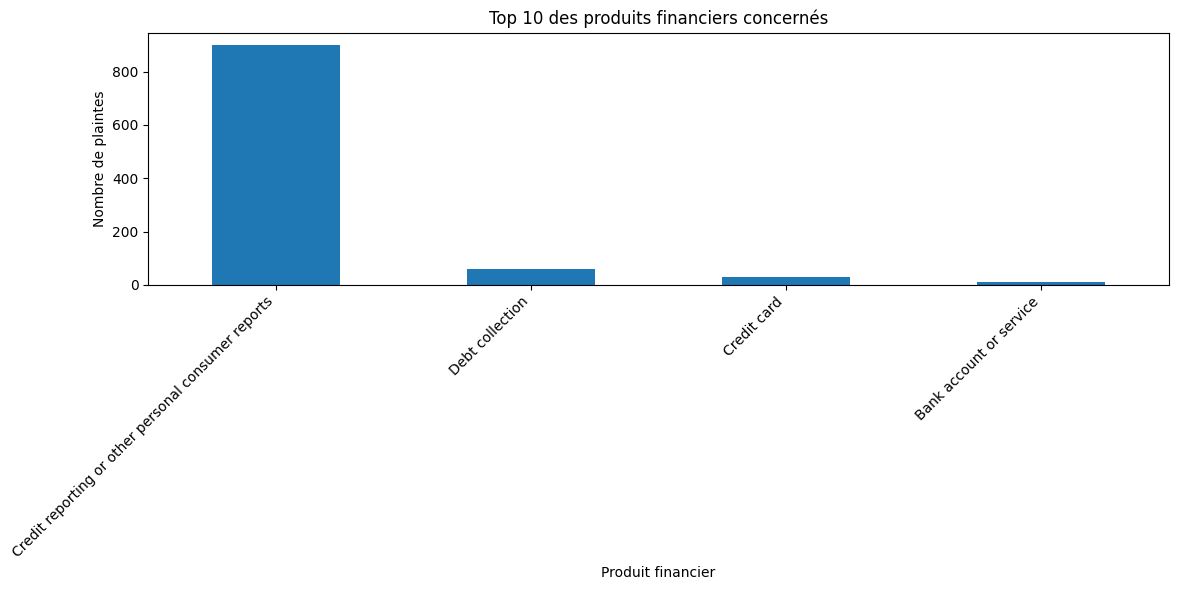

In [ ]:
plt.figure(figsize=(12, 6))

df["product"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 des produits financiers concernés"
)

plt.xlabel(
    "Produit financier"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

**42-Visualiser les problèmes**

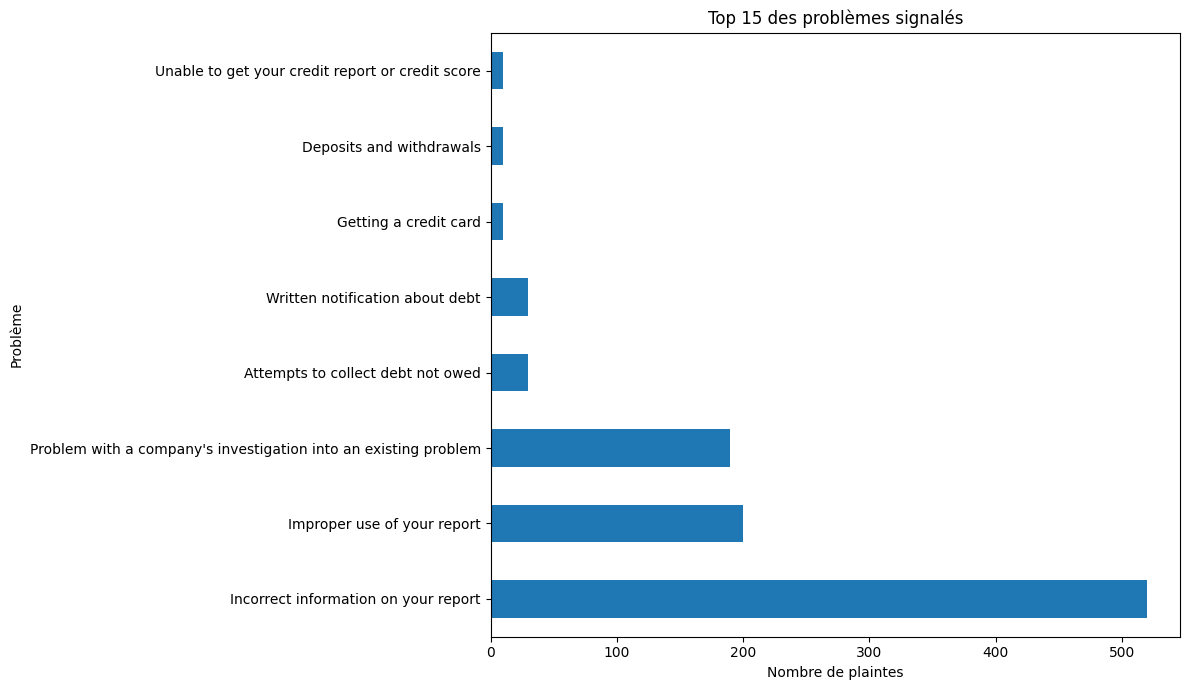

In [ ]:
plt.figure(figsize=(12, 7))

df["issue"].value_counts().head(15).plot(
    kind="barh"
)

plt.title(
    "Top 15 des problèmes signalés"
)

plt.xlabel(
    "Nombre de plaintes"
)

plt.ylabel(
    "Problème"
)

plt.tight_layout()

plt.show()

**43-Visualiser l'évolution temporelle**

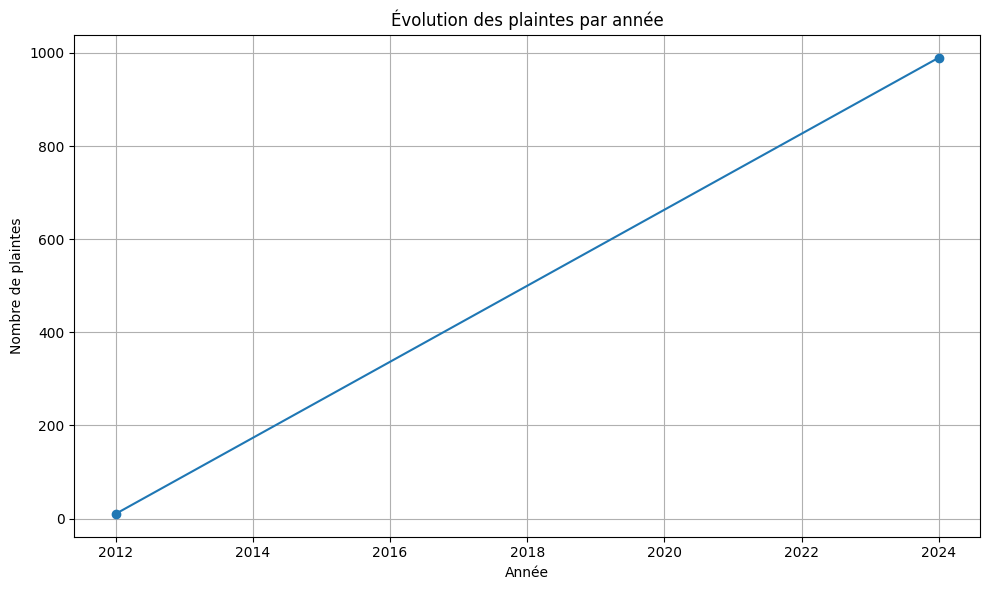

In [ ]:
yearly_complaints = (
    df["year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

yearly_complaints.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Évolution des plaintes par année"
)

plt.xlabel(
    "Année"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.grid(True)

plt.tight_layout()

plt.show()

**43-Sauvegarder notre dataset**

In [ ]:
df.to_csv(
    "data/raw/complaints_raw_1000.csv",
    index=False,
    encoding="utf-8-sig"
)

**44-Créons un dataset spécifique au NLP**

In [ ]:
nlp_columns = [
    "complaint_id",
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "complaint_what_happened",
    "company",
    "date_received",
    "state",
    "submitted_via",
    "company_response",
    "has_narrative"
]

In [ ]:
df_nlp = df[
    nlp_columns
].copy()

**45-Sauvegarder le dataset NLP**

In [ ]:
df_nlp.to_csv(
    "data/raw/complaints_nlp_1000.csv",
    index=False,
    encoding="utf-8-sig"
)

**46-Collectons de 10 000 plaintes**

In [ ]:
TARGET_SIZE = 10_000
BATCH_SIZE = 1000

In [ ]:
df_10000 = collect_complaints(
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE
)

Collecte des plaintes 0 à 1000
Total collecté : 1000
Collecte des plaintes 1000 à 2000
Total collecté : 2000
Collecte des plaintes 2000 à 3000
Total collecté : 3000
Collecte des plaintes 3000 à 4000
Total collecté : 4000
Collecte des plaintes 4000 à 5000
Total collecté : 5000
Collecte des plaintes 5000 à 6000
Total collecté : 6000
Collecte des plaintes 6000 à 7000
Total collecté : 7000
Collecte des plaintes 7000 à 8000
Total collecté : 8000
Collecte des plaintes 8000 à 9000
Total collecté : 9000
Collecte des plaintes 9000 à 10000
Total collecté : 10000


In [ ]:
print(
    "Nombre de lignes :",
    df_10000.shape[0]
)

print(
    "Nombre de colonnes :",
    df_10000.shape[1]
)

Nombre de lignes : 10000
Nombre de colonnes : 17


In [ ]:
print(
    "Nombre de complaint_id uniques :",
    df_10000["complaint_id"].nunique()
)

print(
    "Nombre de doublons :",
    df_10000["complaint_id"].duplicated().sum()
)

Nombre de complaint_id uniques : 1000
Nombre de doublons : 9000


In [ ]:
print(
    df_10000["has_narrative"].value_counts(
        dropna=False
    )
)

has_narrative
False    7260
True     2740
Name: count, dtype: int64


In [ ]:
narrative_percentage = (
    df_10000["has_narrative"].mean() * 100
)

print(
    f"Pourcentage de plaintes avec récit : "
    f"{narrative_percentage:.2f}%"
)

Pourcentage de plaintes avec récit : 27.40%


In [ ]:
os.makedirs(
    "data/raw",
    exist_ok=True
)

df_10000.to_csv(
    "data/raw/complaints_raw_10000.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
print(
    os.path.exists(
        "data/raw/complaints_raw_10000.csv"
    )
)

True


In [ ]:
print(df_10000.shape)

(10000, 17)


In [ ]:
print(df_10000["has_narrative"].value_counts(dropna=False))

has_narrative
False    7260
True     2740
Name: count, dtype: int64


**47-Collecte du dataset final**

In [ ]:
TARGET_SIZE = 50_000
BATCH_SIZE = 1000

print("Taille cible :", TARGET_SIZE)
print("Taille des lots :", BATCH_SIZE)

Taille cible : 50000
Taille des lots : 1000


In [ ]:
df_50000 = collect_complaints(
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE
)

Collecte des plaintes 0 à 1000
Total collecté : 1000
Collecte des plaintes 1000 à 2000
Total collecté : 2000
Collecte des plaintes 2000 à 3000
Total collecté : 3000
Collecte des plaintes 3000 à 4000
Total collecté : 4000
Collecte des plaintes 4000 à 5000
Total collecté : 5000
Collecte des plaintes 5000 à 6000
Total collecté : 6000
Collecte des plaintes 6000 à 7000
Total collecté : 7000
Collecte des plaintes 7000 à 8000
Total collecté : 8000
Collecte des plaintes 8000 à 9000
Total collecté : 9000
Collecte des plaintes 9000 à 10000
Total collecté : 10000
Collecte des plaintes 10000 à 11000
Total collecté : 11000
Collecte des plaintes 11000 à 12000
Total collecté : 12000
Collecte des plaintes 12000 à 13000
Total collecté : 13000
Collecte des plaintes 13000 à 14000
Total collecté : 14000
Collecte des plaintes 14000 à 15000
Total collecté : 15000
Collecte des plaintes 15000 à 16000
Total collecté : 16000
Collecte des plaintes 16000 à 17000
Total collecté : 17000
Collecte des plaintes 17000 

In [ ]:
print(
    "Nombre de lignes :",
    df_50000.shape[0]
)

print(
    "Nombre de colonnes :",
    df_50000.shape[1]
)

Nombre de lignes : 50000
Nombre de colonnes : 17


In [ ]:
print(
    "Nombre d'identifiants uniques :",
    df_50000["complaint_id"].nunique()
)

Nombre d'identifiants uniques : 1000


In [ ]:
print(
    "Nombre de doublons :",
    df_50000["complaint_id"].duplicated().sum()
)

Nombre de doublons : 49000


In [ ]:
print(
    df_50000["has_narrative"].value_counts(
        dropna=False
    )
)

has_narrative
False    36300
True     13700
Name: count, dtype: int64


In [ ]:
narrative_percentage = (
    df_50000["has_narrative"].mean() * 100
)

print(
    f"Pourcentage de plaintes avec récit : "
    f"{narrative_percentage:.2f}%"
)

Pourcentage de plaintes avec récit : 27.40%


In [ ]:
import os

os.makedirs(
    "data/raw",
    exist_ok=True
)

df_50000.to_csv(
    "data/raw/complaints_raw_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
nlp_columns = [
    "complaint_id",
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "complaint_what_happened",
    "company",
    "date_received",
    "state",
    "submitted_via",
    "company_response",
    "has_narrative"
]

df_nlp_50000 = df_50000[
    nlp_columns
].copy()

In [ ]:
df_nlp_50000.to_csv(
    "data/raw/complaints_nlp_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

## **📓 NOTEBOOK 2 — NETTOYAGE ET PRÉTRAITEMENT NLP**

**Étape 1 — Titre du notebook**

**Créons une nouvelle cellule Markdown :**

# Copilote d'intelligence sur les plaintes clients

## Notebook 2 — Nettoyage et prétraitement NLP

### Objectif

Ce notebook a pour objectif de préparer les données textuelles issues
des plaintes clients pour les futurs modèles d'intelligence artificielle.

Les principales étapes sont :

- chargement des données ;
- analyse de la qualité des données ;
- suppression des doublons ;
- gestion des valeurs manquantes ;
- filtrage des plaintes sans récit ;
- nettoyage des textes ;
- normalisation ;
- analyse de la longueur des textes ;
- préparation des variables pour la classification ;
- préparation des données pour le clustering ;
- sauvegarde du dataset nettoyé.

**Étape 2 — Importons les bibliothèques**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import os
import matplotlib.pyplot as plt
import seaborn as sns

**Étape 3 — Chargeons les données**

In [ ]:
df = pd.read_csv(
    "data/raw/complaints_nlp_50000.csv"
)

In [ ]:
print(
    "Nombre de lignes :",
    df.shape[0]
)

print(
    "Nombre de colonnes :",
    df.shape[1]
)

Nombre de lignes : 50000
Nombre de colonnes : 12


**Étape 4 — Affichons les premières lignes**

In [ ]:
df.head()

,complaint_id,product,sub_product,issue,sub_issue,complaint_what_happened,company,date_received,state,submitted_via,company_response,has_narrative
0,9999997,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2024-09-03T22:42:53.000Z,FL,Web,Closed with non-monetary relief,False
1,9999996,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,"EQUIFAX, INC.",2024-09-03T22:42:53.000Z,FL,Web,Closed with non-monetary relief,False
2,9999995,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,"EQUIFAX, INC.",2024-09-03T22:41:36.000Z,NV,Web,Closed with non-monetary relief,False
3,9999994,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,"EQUIFAX, INC.",2024-09-03T22:37:10.000Z,WA,Web,Closed with explanation,False
4,9999989,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Lendmark Financial Services,2024-09-03T22:22:09.000Z,GA,Web,Closed with explanation,False


**Étape 5 — Examinons les colonnes**

In [ ]:
print(
    df.columns.tolist()
)

['complaint_id', 'product', 'sub_product', 'issue', 'sub_issue', 'complaint_what_happened', 'company', 'date_received', 'state', 'submitted_via', 'company_response', 'has_narrative']


**Étape 6 — Informations générales**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   complaint_id             50000 non-null  int64 
 1   product                  50000 non-null  object
 2   sub_product              49650 non-null  object
 3   issue                    50000 non-null  object
 4   sub_issue                48850 non-null  object
 5   complaint_what_happened  13700 non-null  object
 6   company                  50000 non-null  object
 7   date_received            50000 non-null  object
 8   state                    50000 non-null  object
 9   submitted_via            50000 non-null  object
 10  company_response         50000 non-null  object
 11  has_narrative            50000 non-null  bool  
dtypes: bool(1), int64(1), object(10)
memory usage: 4.2+ MB


**Étape 7 — Vérifions les valeurs manquantes**

In [ ]:
missing = df.isnull().sum()

print(
    missing.sort_values(
        ascending=False
    )
)

complaint_what_happened    36300
sub_issue                   1150
sub_product                  350
complaint_id                   0
issue                          0
product                        0
company                        0
date_received                  0
state                          0
submitted_via                  0
company_response               0
has_narrative                  0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(
    ascending=False
)

print(
    missing_percentage
)

complaint_what_happened    72.6
sub_issue                   2.3
sub_product                 0.7
complaint_id                0.0
issue                       0.0
product                     0.0
company                     0.0
date_received               0.0
state                       0.0
submitted_via               0.0
company_response            0.0
has_narrative               0.0
dtype: float64


**Étape 8 — Vérifions les doublons**

In [ ]:
print(
    "Nombre de doublons :",
    df["complaint_id"].duplicated().sum()
)

Nombre de doublons : 49000


**Étape 9 — Supprimons les doublons**

In [ ]:
df = df.drop_duplicates(
    subset="complaint_id"
).copy()

In [ ]:
print(
    "Nombre de lignes après suppression :",
    len(df)
)

Nombre de lignes après suppression : 1000


**Étape 10 — Vérifions les récits**

In [ ]:
df["has_narrative"].value_counts(
    dropna=False
)

,count
has_narrative,
False,726
True,274


**Étape 11 — Gardons uniquement les plaintes avec récit**

In [ ]:
df_nlp = df[
    df["has_narrative"] == True
].copy()

In [ ]:
print(
    "Nombre de plaintes avec récit :",
    len(df_nlp)
)

Nombre de plaintes avec récit : 274


In [ ]:
print(
    "Pourcentage conservé :",
    round(
        len(df_nlp) / len(df) * 100,
        2
    ),
    "%"
)

Pourcentage conservé : 27.4 %


**Étape 12 — Vérifions les textes vides**

In [ ]:
df_nlp[
    "complaint_what_happened"
] = df_nlp[
    "complaint_what_happened"
].fillna("")

In [ ]:
empty_texts = (
    df_nlp[
        "complaint_what_happened"
    ]
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Nombre de textes vides :",
    empty_texts
)

Nombre de textes vides : 0


**Étape 13 — Créons une copie du texte original**

In [ ]:
df_nlp[
    "text_original"
] = df_nlp[
    "complaint_what_happened"
]

**Étape 14 — Créons une fonction de nettoyage**

In [ ]:
def clean_text(text):

    # Convertir en chaîne de caractères
    text = str(text)

    # Convertir en minuscules
    text = text.lower()

    # Supprimer les URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Supprimer les emails
    text = re.sub(
        r"\S+@\S+",
        "",
        text
    )

    # Supprimer les caractères spéciaux
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # Supprimer les espaces multiples
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Supprimer les espaces au début et à la fin
    text = text.strip()

    return text

**Étape 15 — Appliquons le nettoyage**

In [ ]:
df_nlp[
    "text_clean"
] = df_nlp[
    "text_original"
].apply(
    clean_text
)

**Étape 16 — Comparons avant / après**

In [ ]:
df_nlp[
    [
        "text_original",
        "text_clean"
    ]
].head()

,text_original,text_clean
9,Chae bank called me about a fraudulent case ap...,chae bank called me about a fraudulent case ap...
10,The inclusion of these unauthorized accounts a...,the inclusion of these unauthorized accounts a...
15,I respectfully seek your comprehension regardi...,i respectfully seek your comprehension regardi...
17,"Upon reviewing my credit report, I identified ...",upon reviewing my credit report i identified m...
20,sent letters to aargon agency asking for valid...,sent letters to aargon agency asking for valid...


**Étape 17 — Calculons la longueur des textes**

In [ ]:
df_nlp[
    "text_length"
] = df_nlp[
    "text_clean"
].str.len()

In [ ]:
df_nlp[
    "text_length"
].describe()

,text_length
count,274.000000
mean,783.131387
std,991.584792
min,64.000000
25%,268.000000
50%,442.000000
75%,972.500000
max,10158.000000


**Étape 18 — Visualisons la longueur des textes**

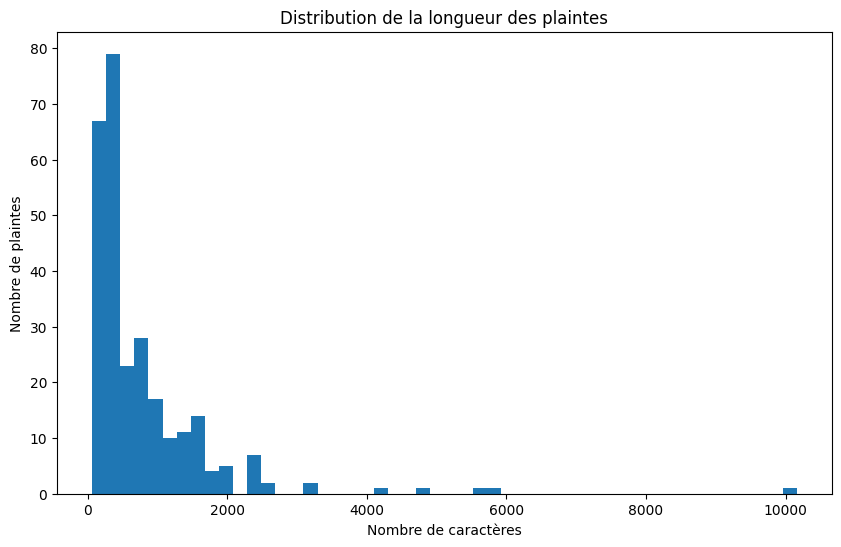

In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df_nlp[
        "text_length"
    ],
    bins=50
)

plt.title(
    "Distribution de la longueur des plaintes"
)

plt.xlabel(
    "Nombre de caractères"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.show()

**Étape 19 — Supprimons les textes trop courts**

In [ ]:
df_nlp = df_nlp[
    df_nlp[
        "text_length"
    ] >= 20
].copy()

In [ ]:
print(
    "Nombre de plaintes après filtrage :",
    len(df_nlp)
)

Nombre de plaintes après filtrage : 274


**Étape 20 — Vérifions la distribution des produits**

In [ ]:
df_nlp[
    "product"
].value_counts().head(20)

,count
product,
Credit reporting or other personal consumer reports,230
Debt collection,20
Vehicle loan or lease,7
Checking or savings account,7
Credit card,5
Mortgage,2
"Payday loan, title loan, personal loan, or advance loan",1
"Money transfer, virtual currency, or money service",1
Student loan,1


**Étape 21 — Vérifions la distribution des problèmes**

In [ ]:
df_nlp[
    "issue"
].value_counts().head(20)

,count
issue,
Incorrect information on your report,127
Problem with a company's investigation into an existing problem,51
Improper use of your report,50
Attempts to collect debt not owed,9
Written notification about debt,8
Managing an account,5
Managing the loan or lease,4
Took or threatened to take negative or legal action,2
Getting a credit card,2


**Étape 22 — Vérifions les classes**

In [ ]:
class_distribution = (
    df_nlp[
        "product"
    ]
    .value_counts()
)

print(
    class_distribution
)

product
Credit reporting or other personal consumer reports        230
Debt collection                                             20
Vehicle loan or lease                                        7
Checking or savings account                                  7
Credit card                                                  5
Mortgage                                                     2
Payday loan, title loan, personal loan, or advance loan      1
Money transfer, virtual currency, or money service           1
Student loan                                                 1
Name: count, dtype: int64


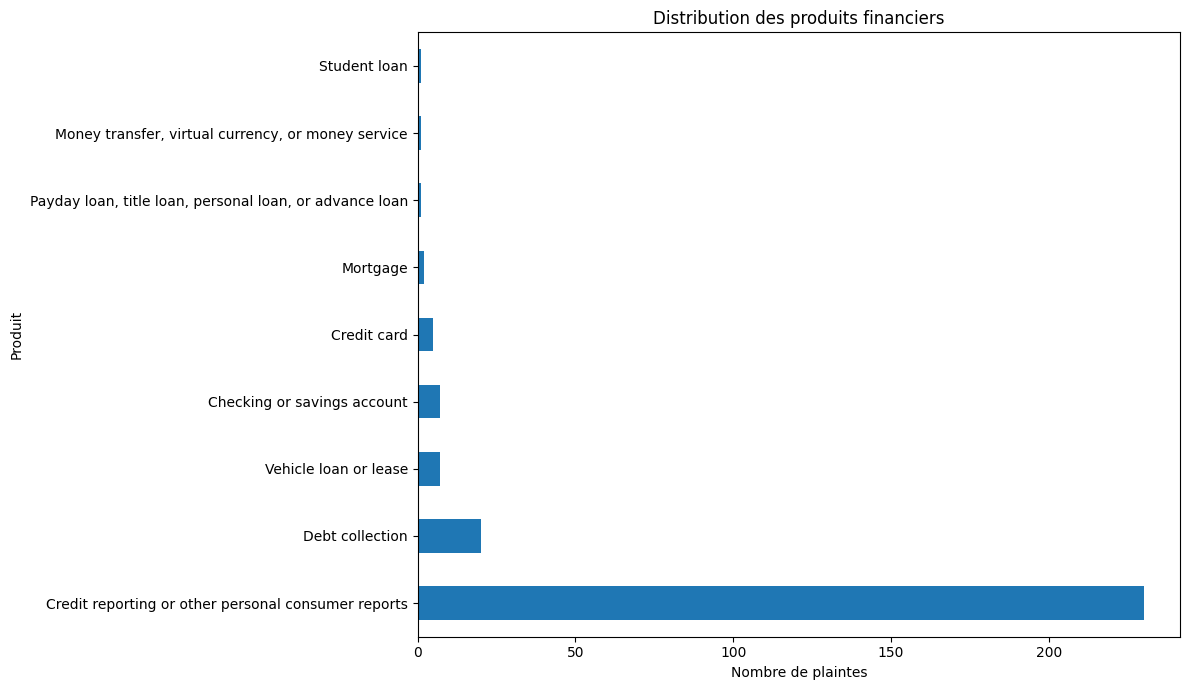

In [ ]:
plt.figure(
    figsize=(12, 7)
)

class_distribution.head(15).plot(
    kind="barh"
)

plt.title(
    "Distribution des produits financiers"
)

plt.xlabel(
    "Nombre de plaintes"
)

plt.ylabel(
    "Produit"
)

plt.tight_layout()

plt.show()

**Étape 23 — Préparons les dates**

In [ ]:
df_nlp[
    "date_received"
] = pd.to_datetime(
    df_nlp[
        "date_received"
    ],
    errors="coerce"
)

In [ ]:
df_nlp[
    "year"
] = df_nlp[
    "date_received"
].dt.year

df_nlp[
    "month"
] = df_nlp[
    "date_received"
].dt.month

**Étape 24 — Créons un identifiant numérique**

In [ ]:
df_nlp = df_nlp.reset_index(
    drop=True
)

df_nlp[
    "text_id"
] = np.arange(
    len(df_nlp)
)

**Étape 25 — Vérification finale**

In [ ]:
print(
    "Nombre final de plaintes NLP :",
    len(df_nlp)
)

print(
    "Nombre de colonnes :",
    len(df_nlp.columns)
)

Nombre final de plaintes NLP : 274
Nombre de colonnes : 18


In [ ]:
df_nlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   complaint_id             274 non-null    int64              
 1   product                  274 non-null    object             
 2   sub_product              274 non-null    object             
 3   issue                    274 non-null    object             
 4   sub_issue                271 non-null    object             
 5   complaint_what_happened  274 non-null    object             
 6   company                  274 non-null    object             
 7   date_received            274 non-null    datetime64[ns, UTC]
 8   state                    274 non-null    object             
 9   submitted_via            274 non-null    object             
 10  company_response         274 non-null    object             
 11  has_narrative            274 non

**Étape 26 — Sauvegardons les données nettoyées**

In [ ]:
os.makedirs(
    "data/processed",
    exist_ok=True
)

In [ ]:
df_nlp.to_csv(
    "data/processed/complaints_clean_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

## **📓 NOTEBOOK 3 — CLASSIFICATION DES PLAINTES CLIENTS**

**Étape 1 — Chargeons les bibliothèques**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

**Étape 2 — Chargeons le dataset nettoyé**

In [ ]:
df = pd.read_csv(
    "data/processed/complaints_clean_50000.csv"
)

In [ ]:
print(
    "Nombre de plaintes :",
    len(df)
)

print(
    "Nombre de colonnes :",
    len(df.columns)
)

Nombre de plaintes : 274
Nombre de colonnes : 18


**Étape 3 — Vérifions la variable cible**

In [ ]:
target = "product"

In [ ]:
df[
    target
].value_counts()

,count
product,
Credit reporting or other personal consumer reports,230
Debt collection,20
Vehicle loan or lease,7
Checking or savings account,7
Credit card,5
Mortgage,2
"Payday loan, title loan, personal loan, or advance loan",1
"Money transfer, virtual currency, or money service",1
Student loan,1


**Étape 4 — Vérifions les textes**

In [ ]:
text_column = "text_clean"

In [ ]:
print(
    df[
        text_column
    ].isnull().sum()
)

0


In [ ]:
df = df.dropna(
    subset=[
        text_column,
        target
    ]
).copy()

**Étape 5 — Définissons X et y**

In [ ]:
X = df[
    text_column
]

y = df[
    target
]

In [ ]:
print(
    "X :", X.shape
)

print(
    "y :", y.shape
)

X : (274,)
y : (274,)


**Étape 6 — Séparons les données**

In [ ]:
class_counts = y.value_counts()
problematic_classes = class_counts[class_counts < 2].index.tolist()

# Filter out rows belonging to problematic classes
df = df[~df[target].isin(problematic_classes)].copy()

# Redefine X and y with the filtered DataFrame
X = df[
    text_column
]

y = df[
    target
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(
    "Train :",
    len(X_train)
)

print(
    "Test :",
    len(X_test)
)

Train : 216
Test : 55


**Étape 7 — Créons le vectoriseur TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

**Étape 8 — Transformons les textes**

In [ ]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

In [ ]:
X_test_tfidf = tfidf.transform(
    X_test
)

In [ ]:
print(
    "Train TF-IDF :",
    X_train_tfidf.shape
)

print(
    "Test TF-IDF :",
    X_test_tfidf.shape
)

Train TF-IDF : (216, 4024)
Test TF-IDF : (55, 4024)


**Étape 9 — Entraînons le modèle**

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [ ]:
model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

**Étape 10 — Faisons les prédictions**

In [ ]:
y_pred = model.predict(
    X_test_tfidf
)

In [ ]:
y_pred

array(['Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       'Credit reporting or other personal consumer reports',
       '

**Étape 11 — Calculons le Macro-F1**

In [ ]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    "Macro-F1 :",
    round(
        macro_f1,
        4
    )
)

Macro-F1 : 0.4945


**Étape 12 — Calculons l'Accuracy**

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy :",
    round(
        accuracy,
        4
    )
)

Accuracy : 0.9091


**Étape 13 — Rapport de classification**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                                                     precision    recall  f1-score   support

                        Checking or savings account       1.00      0.50      0.67         2
                                        Credit card       0.00      0.00      0.00         1
Credit reporting or other personal consumer reports       0.92      0.98      0.95        47
                                    Debt collection       1.00      0.75      0.86         4
                              Vehicle loan or lease       0.00      0.00      0.00         1

                                           accuracy                           0.91        55
                                          macro avg       0.58      0.45      0.49        55
                                       weighted avg       0.90      0.91      0.90        55



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Étape 14 — Matrice de confusion**

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

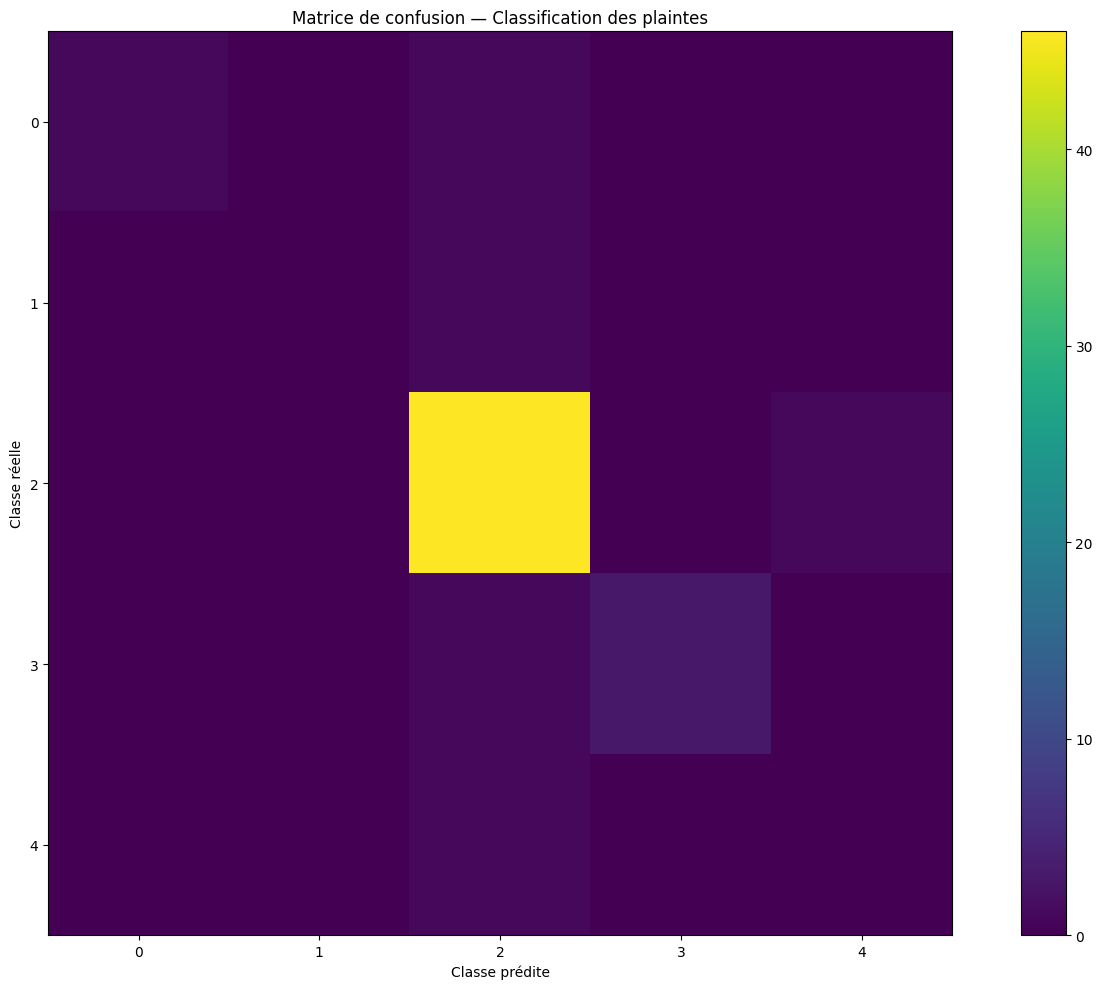

In [ ]:
plt.figure(
    figsize=(14, 10)
)

plt.imshow(
    cm
)

plt.title(
    "Matrice de confusion — Classification des plaintes"
)

plt.xlabel(
    "Classe prédite"
)

plt.ylabel(
    "Classe réelle"
)

plt.colorbar()

plt.tight_layout()

plt.show()

**Étape 15 — Identifions les erreurs**

In [ ]:
results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

In [ ]:
errors = results[
    results["actual"] != results["predicted"]
].copy()

In [ ]:
print(
    "Nombre d'erreurs :",
    len(errors)
)

Nombre d'erreurs : 5


**Étape 16 — Examinons les erreurs**

In [ ]:
errors.head(10)

,text,actual,predicted
16,have tried over xxxx times to set up account v...,Credit reporting or other personal consumer re...,Vehicle loan or lease
20,received a letter from transworld systems inco...,Debt collection,Credit reporting or other personal consumer re...
25,i xxxx xxxx on this xx xx xxxx submit this cfp...,Credit card,Credit reporting or other personal consumer re...
45,notice to cease and desist all collection acti...,Vehicle loan or lease,Credit reporting or other personal consumer re...
46,i received a bank statement from marcus by gol...,Checking or savings account,Credit reporting or other personal consumer re...


**Étape 17 — Analysons les performances par classe**

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
report_df = pd.DataFrame(
    report
).transpose()

In [ ]:
report_df.sort_values(
    "f1-score"
)

,precision,recall,f1-score,support
Credit card,0.000000,0.000000,0.000000,1.000000
Vehicle loan or lease,0.000000,0.000000,0.000000,1.000000
macro avg,0.584000,0.445745,0.494453,55.000000
Checking or savings account,1.000000,0.500000,0.666667,2.000000
Debt collection,1.000000,0.750000,0.857143,4.000000
weighted avg,0.895273,0.909091,0.897077,55.000000
accuracy,0.909091,0.909091,0.909091,0.909091
Credit reporting or other personal consumer reports,0.920000,0.978723,0.948454,47.000000


**Étape 18 — Sauvegardons le modèle**

In [ ]:
import joblib

In [ ]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [ ]:
joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

['models/tfidf_vectorizer.pkl']

In [ ]:
joblib.dump(
    model,
    "models/complaint_classifier.pkl"
)

['models/complaint_classifier.pkl']

## **📓 NOTEBOOK 4 — CLUSTERING ET DÉCOUVERTE AUTOMATIQUE DES THÈMES**



**Étape 1 — Titre du notebook**
# Copilote d'intelligence sur les plaintes clients

## Notebook 4 — Clustering et découverte automatique des thèmes

### Objectif

Ce notebook vise à identifier automatiquement les thèmes et groupes
de plaintes similaires à partir de leur contenu textuel.

Les principales étapes sont :

- chargement des données nettoyées ;
- génération des embeddings sémantiques ;
- réduction dimensionnelle ;
- clustering non supervisé ;
- recherche du nombre optimal de clusters ;
- évaluation avec le Silhouette Score ;
- analyse des mots-clés de chaque cluster ;
- interprétation des thèmes ;
- identification des thèmes émergents.

**Étape 2 — Installons les bibliothèques**

In [ ]:
!pip install -q sentence-transformers scikit-learn

**Étape 3 — Importons les bibliothèques**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import TfidfVectorizer

import os
import joblib

**Étape 4 — Chargeons le dataset**

In [ ]:
df = pd.read_csv(
    "data/processed/complaints_clean_50000.csv"
)

In [ ]:
print(
    "Nombre de plaintes :",
    len(df)
)

print(
    "Nombre de colonnes :",
    len(df.columns)
)

Nombre de plaintes : 274
Nombre de colonnes : 18


**Étape 5 — Vérifions les textes**

In [ ]:
text_column = "text_clean"

In [ ]:
print(
    "Textes manquants :",
    df[text_column].isnull().sum()
)

Textes manquants : 0


**Étape 6 — Supprimons les textes manquants**

In [ ]:
df = df.dropna(
    subset=[
        text_column
    ]
).copy()

In [ ]:
df = df[
    df[text_column].str.strip() != ""
].copy()

In [ ]:
print(
    "Nombre de plaintes utilisables :",
    len(df)
)

Nombre de plaintes utilisables : 274


**Étape 7 — Préparons les textes**

In [ ]:
texts = df[
    text_column
].tolist()

In [ ]:
print(
    "Nombre de textes :",
    len(texts)
)

Nombre de textes : 274


In [ ]:
print(
    texts[0]
)

chae bank called me about a fraudulent case application they gave me a case number xxxx tranferred me cfpb during the call long silent when agent said is looking at the report then cut off no call back was done


**Étape 8 — Chargeons le modèle d'embeddings**

In [ ]:
model_name = "all-MiniLM-L6-v2"

In [ ]:
embedding_model = SentenceTransformer(
    model_name
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Étape 9 — Générons les embeddings**

In [ ]:
embeddings = embedding_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
print(
    "Dimensions des embeddings :",
    embeddings.shape
)

Dimensions des embeddings : (274, 384)


In [ ]:
import torch

print(
    "GPU disponible :",
    torch.cuda.is_available()
)

GPU disponible : False


**Étape 10 — Sauvegardons les embeddings**

In [ ]:
os.makedirs(
    "data/processed",
    exist_ok=True
)

In [ ]:
np.save(
    "data/processed/complaint_embeddings.npy",
    embeddings
)

**Étape 11 — Vérifions le fichier**

In [ ]:
print(
    os.path.exists(
        "data/processed/complaint_embeddings.npy"
    )
)

True


**Étape 12 — Chargeons les embeddings ultérieurement**

In [ ]:
embeddings = np.load(
    "data/processed/complaint_embeddings.npy"
)

**Étape 13 — Testons plusieurs nombres de clusters**

In [ ]:
k_values = [
    5,
    10,
    15,
    20,
    25
]

In [ ]:
silhouette_scores = []

In [ ]:
for k in k_values:

    print(
        f"Entraînement K-Means avec K={k}"
    )

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        embeddings
    )

    score = silhouette_score(
        embeddings,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(
        score
    )

    print(
        f"Silhouette Score : {score:.4f}"
    )

Entraînement K-Means avec K=5
Silhouette Score : 0.0861
Entraînement K-Means avec K=10
Silhouette Score : 0.1263
Entraînement K-Means avec K=15
Silhouette Score : 0.1560
Entraînement K-Means avec K=20
Silhouette Score : 0.1820
Entraînement K-Means avec K=25
Silhouette Score : 0.2045


**Étape 14 — Visualisons le Silhouette Score**

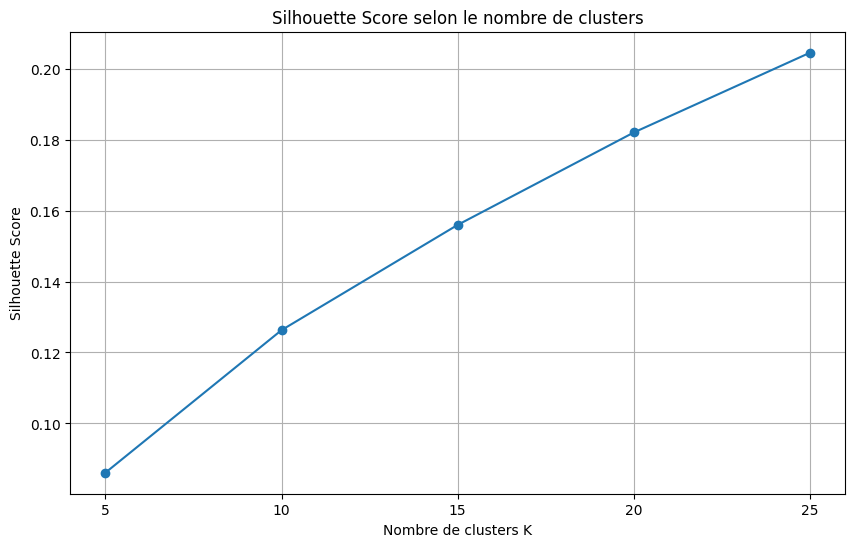

In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score selon le nombre de clusters"
)

plt.xlabel(
    "Nombre de clusters K"
)

plt.ylabel(
    "Silhouette Score"
)

plt.xticks(
    k_values
)

plt.grid(
    True
)

plt.show()

**Étape 15 — Sélectionnons le meilleur K**

In [ ]:
best_k = k_values[
    np.argmax(
        silhouette_scores
    )
]

print(
    "Meilleur nombre de clusters :",
    best_k
)

Meilleur nombre de clusters : 25


**Étape 16 — Entraînons le modèle final**

In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

In [ ]:
df[
    "cluster"
] = kmeans.fit_predict(
    embeddings
)

**Étape 17 — Vérifions la taille des clusters**

In [ ]:
cluster_distribution = (
    df[
        "cluster"
    ]
    .value_counts()
    .sort_index()
)

print(
    cluster_distribution
)

cluster
0     25
1      4
2     14
3     18
4     26
5     14
6      4
7     15
8     20
9      9
10     7
11     6
12    16
13     7
14     2
15     6
16     6
17     4
18     2
19    13
20    13
21    13
22     4
23     7
24    19
Name: count, dtype: int64


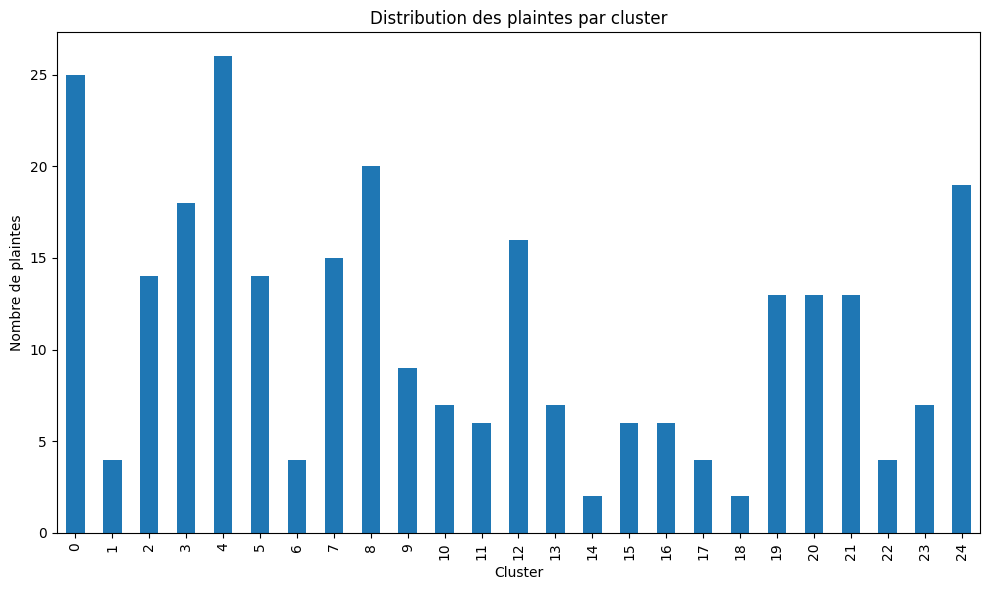

In [ ]:
plt.figure(
    figsize=(10, 6)
)

cluster_distribution.plot(
    kind="bar"
)

plt.title(
    "Distribution des plaintes par cluster"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.tight_layout()

plt.show()

**Étape 18 — Réduire les embeddings en 2 dimensions**

In [ ]:
pca = PCA(
    n_components=2,
    random_state=42
)

In [ ]:
embeddings_2d = pca.fit_transform(
    embeddings
)

In [ ]:
print(
    embeddings_2d.shape
)

(274, 2)


**Étape 19 — Visualisons les clusters**

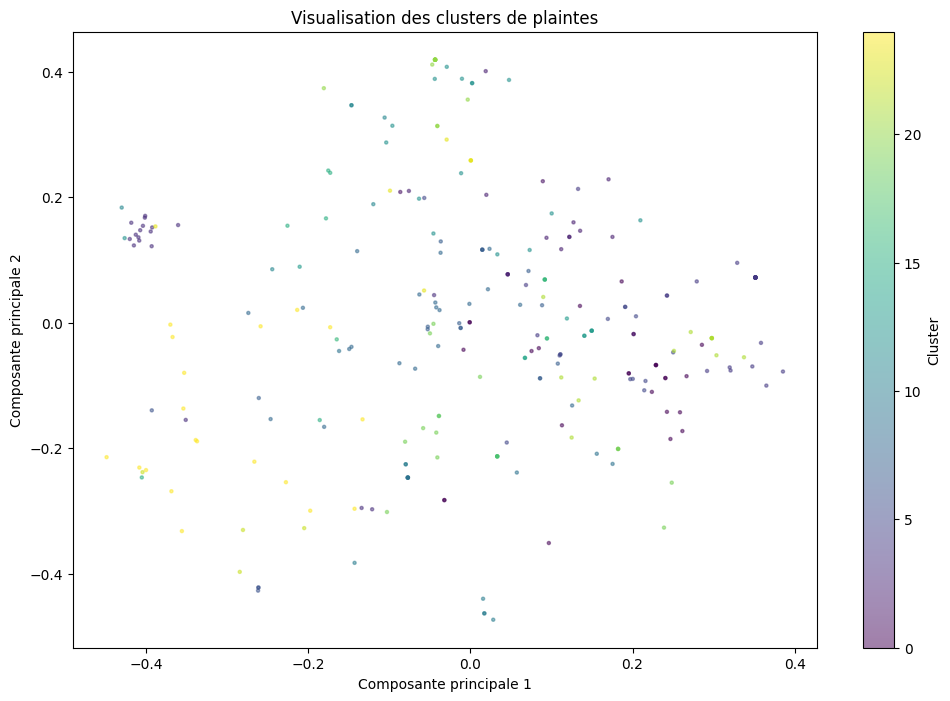

In [ ]:
plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster"],
    s=5,
    alpha=0.5
)

plt.title(
    "Visualisation des clusters de plaintes"
)

plt.xlabel(
    "Composante principale 1"
)

plt.ylabel(
    "Composante principale 2"
)

plt.colorbar(
    label="Cluster"
)

plt.show()

**Étape 20 — Identifions les mots-clés des clusters**

In [ ]:
tfidf_cluster = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

In [ ]:
X_tfidf_cluster = tfidf_cluster.fit_transform(
    df[text_column]
)

In [ ]:
terms = np.array(
    tfidf_cluster.get_feature_names_out()
)

**Étape 21 — Fonction pour extraire les mots-clés**

In [ ]:
def get_top_terms(
    cluster_id,
    n_terms=10
):

    cluster_indices = (
        df["cluster"] == cluster_id
    ).to_numpy() # Convert Series to numpy array

    cluster_tfidf = (
        X_tfidf_cluster[
            cluster_indices
        ]
    )

    mean_scores = np.asarray(
        cluster_tfidf.mean(
            axis=0
        )
    ).flatten()

    top_indices = mean_scores.argsort()[
        -n_terms:
    ][::-1]

    return terms[
        top_indices
    ]

**Étape 22 — Affichons les thèmes**

In [ ]:
for cluster_id in sorted(
    df["cluster"].unique()
):

    top_terms = get_top_terms(
        cluster_id,
        n_terms=15
    )

    print(
        f"\nCluster {cluster_id}"
    )

    print(
        ", ".join(
            top_terms
        )
    )


Cluster 0
xxxx, xxxx xxxx, accounts, report, credit report, credit, incorrect, unjust, accounts credit, fraudulent, incorrect accounts, added, authorized, reviewing, reputation

Cluster 1
exposed data, exposed, breach, xxxx, informaton, informaton exposed, breach inaccurate, data breach, xxxx xxxx, data, inaccurate accounts, accounts information, information report, information, reporting incorrect

Cluster 2
credit, inaccurate information, reporting, credit report, rights, errors, fcra, inaccurate, consumer, report, information, rights consumer, right, new credit, life

Cluster 3
payment, late, payments, creditor, error, late payment, usc, consumer, payment date, creditor treat, mailed delivered, delivered, treat payment, days payment, treat

Cluster 4
credit, accounts, investigate, investigate accounts, accounts accordingly, deny credit, credit duty, deny, creditors deny, causing creditors, consumers investigate, accordingly avoid, accounts inquires, inquires update, future litigati

**Étape 23 — Examinons des plaintes par cluster**

In [ ]:
for cluster_id in sorted(
    df["cluster"].unique()
):

    print(
        "\n" + "=" * 80
    )

    print(
        f"CLUSTER {cluster_id}"
    )

    samples = df[
        df["cluster"] == cluster_id
    ][
        [
            "product",
            "issue",
            "text_clean"
        ]
    ].head(3)

    for _, row in samples.iterrows():

        print(
            "\nProduit :",
            row["product"]
        )

        print(
            "Problème :",
            row["issue"]
        )

        print(
            "Plainte :",
            row["text_clean"][:500]
        )


CLUSTER 0

Produit : Debt collection
Problème : Attempts to collect debt not owed
Plainte : upon reviewing my credit report i identified multiple accounts that appear to be fraudulent and were added without my consent

Produit : Credit reporting or other personal consumer reports
Problème : Incorrect information on your report
Plainte : im reaching out for your help regarding the incorrect account listed on my credit report this situation has damaged my reputation and i urgently need your help the way youve handled my credit report has left me struggling as the inaccurate information has seriously tarnished my reputation its crucial that these errors are corrected so i can move forward with my family

Produit : Credit reporting or other personal consumer reports
Problème : Incorrect information on your report
Plainte : i have submitted multiple disputes regarding these accounts that is reporting inaccurately on my credit report i have also submitted multiple reports regarding the acco

**Étape 24 — Comparons les clusters aux catégories officielles**

In [ ]:
cluster_product = pd.crosstab(
    df["cluster"],
    df["product"]
)

In [ ]:
cluster_product

product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,Debt collection,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Student loan,Vehicle loan or lease
cluster,,,,,,,,,
0,1,0,18,6,0,0,0,0,0
1,0,0,4,0,0,0,0,0,0
2,0,0,14,0,0,0,0,0,0
3,0,0,18,0,0,0,0,0,0
4,0,0,25,1,0,0,0,0,0
5,0,0,14,0,0,0,0,0,0
6,0,0,3,1,0,0,0,0,0
7,0,0,14,1,0,0,0,0,0
8,0,2,17,0,0,0,1,0,0


In [ ]:
cluster_product_percentage = (
    pd.crosstab(
        df["cluster"],
        df["product"],
        normalize="index"
    ) * 100
)

In [ ]:
cluster_product_percentage.round(
    2
)

product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,Debt collection,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Student loan,Vehicle loan or lease
cluster,,,,,,,,,
0,4.00,0.00,72.00,24.00,0.00,0.00,0.0,0.00,0.00
1,0.00,0.00,100.00,0.00,0.00,0.00,0.0,0.00,0.00
2,0.00,0.00,100.00,0.00,0.00,0.00,0.0,0.00,0.00
3,0.00,0.00,100.00,0.00,0.00,0.00,0.0,0.00,0.00
4,0.00,0.00,96.15,3.85,0.00,0.00,0.0,0.00,0.00
5,0.00,0.00,100.00,0.00,0.00,0.00,0.0,0.00,0.00
6,0.00,0.00,75.00,25.00,0.00,0.00,0.0,0.00,0.00
7,0.00,0.00,93.33,6.67,0.00,0.00,0.0,0.00,0.00
8,0.00,10.00,85.00,0.00,0.00,0.00,5.0,0.00,0.00


**Étape 25 — Sauvegardons les résultats**

In [ ]:
df.to_csv(
    "data/processed/complaints_clustered_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

**Étape 26 — Sauvegardons le modèle K-Means**

In [ ]:
joblib.dump(
    kmeans,
    "models/kmeans_complaints.pkl"
)

['models/kmeans_complaints.pkl']

In [ ]:
joblib.dump(
    embedding_model,
    "models/embedding_model.pkl"
)

['models/embedding_model.pkl']

## **📓 NOTEBOOK 5 — DÉTECTION D'ANOMALIES ET SYSTÈME D'ALERTES**

Étape 1 — Titre du notebook

Crée une cellule Markdown :

# Copilote d'intelligence sur les plaintes clients

## Notebook 5 — Détection d'anomalies et système d'alertes

### Objectif

Ce notebook vise à identifier automatiquement les plaintes atypiques,
les comportements inhabituels et les évolutions soudaines dans les
réclamations clients.

Le système combine :

- les embeddings sémantiques ;
- le clustering ;
- la distance aux centroïdes ;
- l'analyse temporelle ;
- la détection de pics de plaintes ;
- la génération d'alertes de risque.

Les alertes produites sont des signaux d'aide à la décision et
ne constituent pas à elles seules une preuve de fraude ou de risque.

**Étape 2 — Importer les bibliothèques**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib
import os

from sklearn.metrics import pairwise_distances

**Étape 3 — Charger les données**

In [ ]:
df = pd.read_csv(
    "data/processed/complaints_clustered_50000.csv"
)

In [ ]:
print(
    "Nombre de plaintes :",
    len(df)
)

print(
    "Nombre de colonnes :",
    len(df.columns)
)

Nombre de plaintes : 274
Nombre de colonnes : 19


**Étape 4 — Charger les embeddings**

In [ ]:
embeddings = np.load(
    "data/processed/complaint_embeddings.npy"
)

In [ ]:
print(
    "Dimensions des embeddings :",
    embeddings.shape
)

Dimensions des embeddings : (274, 384)


**Étape 5 — Vérifier les clusters**

In [ ]:
print(
    df["cluster"].value_counts().sort_index()
)

cluster
0     25
1      4
2     14
3     18
4     26
5     14
6      4
7     15
8     20
9      9
10     7
11     6
12    16
13     7
14     2
15     6
16     6
17     4
18     2
19    13
20    13
21    13
22     4
23     7
24    19
Name: count, dtype: int64


## **PARTIE A — DÉTECTION D'ANOMALIES SÉMANTIQUES**

**Étape 6 — Charger le modèle K-Means**

In [ ]:
kmeans = joblib.load(
    "models/kmeans_complaints.pkl"
)

**Étape 7 — Récupérer les centroïdes**

In [ ]:
centroids = kmeans.cluster_centers_

In [ ]:
print(
    "Dimensions des centroïdes :",
    centroids.shape
)

Dimensions des centroïdes : (25, 384)


**Étape 8 — Calculer la distance au centroïde**

In [ ]:
distances = np.zeros(
    len(embeddings)
)

In [ ]:
for cluster_id in range(
    len(centroids)
):

    indices = np.where(
        df["cluster"].values == cluster_id
    )[0]

    if len(indices) > 0:

        distances[indices] = np.linalg.norm(
            embeddings[indices]
            - centroids[cluster_id],
            axis=1
        )

In [ ]:
df[
    "anomaly_score"
] = distances

**Étape 9 — Examiner les scores**

In [ ]:
df[
    "anomaly_score"
].describe()

,anomaly_score
count,2.740000e+02
mean,4.866185e-01
std,2.045696e-01
min,2.143027e-08
25%,3.173628e-01
50%,5.301288e-01
75%,6.227051e-01
max,8.880706e-01


**Étape 10 — Visualiser la distribution**

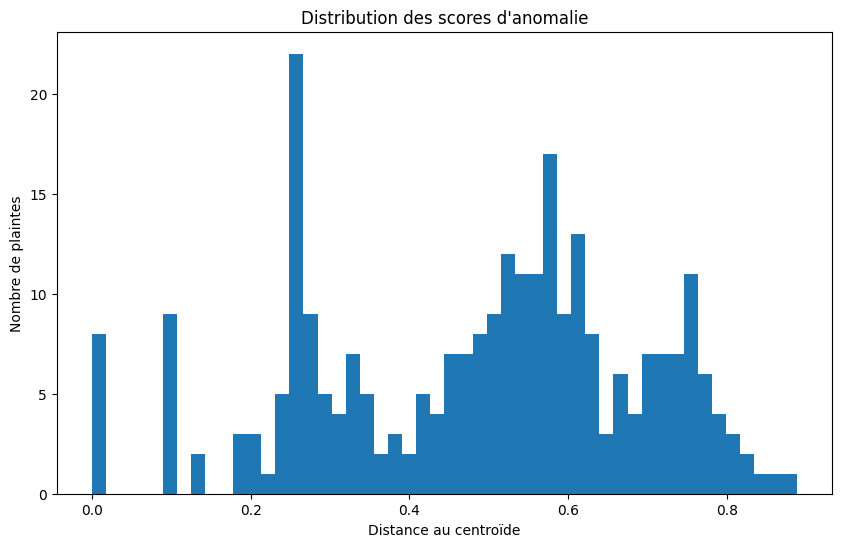

In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df["anomaly_score"],
    bins=50
)

plt.title(
    "Distribution des scores d'anomalie"
)

plt.xlabel(
    "Distance au centroïde"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.show()

**Étape 11 — Définir un seuil d'anomalie**

In [ ]:
anomaly_threshold = np.percentile(
    df["anomaly_score"],
    95
)

print(
    "Seuil d'anomalie :",
    anomaly_threshold
)

Seuil d'anomalie : 0.7695303827524185


**Étape 12 — Créer la variable d'anomalie**

In [ ]:
df[
    "is_anomaly"
] = (
    df["anomaly_score"]
    >= anomaly_threshold
)

In [ ]:
print(
    df[
        "is_anomaly"
    ].value_counts()
)

is_anomaly
False    260
True      14
Name: count, dtype: int64


**Étape 13 — Calculer le pourcentage d'anomalies**

In [ ]:
anomaly_percentage = (
    df["is_anomaly"].mean()
    * 100
)

print(
    f"Pourcentage d'anomalies : "
    f"{anomaly_percentage:.2f}%"
)

Pourcentage d'anomalies : 5.11%


**Étape 14 — Examiner les plaintes atypiques**

In [ ]:
anomalies = df[
    df["is_anomaly"] == True
].copy()

In [ ]:
anomalies[
    [
        "complaint_id",
        "product",
        "issue",
        "cluster",
        "anomaly_score",
        "text_clean"
    ]
].sort_values(
    "anomaly_score",
    ascending=False
).head(20)

,complaint_id,product,issue,cluster,anomaly_score,text_clean
2,9999977,Credit reporting or other personal consumer re...,Incorrect information on your report,9,0.888071,i respectfully seek your comprehension regardi...
165,9999323,Credit card,Getting a credit card,8,0.856932,i xxxx xxxx on this xx xx xxxx submit this cfp...
188,9999255,Debt collection,Written notification about debt,24,0.842910,received a letter from transworld systems inco...
176,9999295,Vehicle loan or lease,Problems at the end of the loan or lease,15,0.831511,i bought a xxxx from a 3rd party dealership on...
260,9998969,Debt collection,Written notification about debt,24,0.830007,i have a debt that has now been listed on my c...
196,9999230,Vehicle loan or lease,Managing the loan or lease,19,0.815257,creditor keeps calling my workplace after bein...
110,9999523,Vehicle loan or lease,Getting a loan or lease,12,0.802016,notice to cease and desist all collection acti...
227,9999104,Credit reporting or other personal consumer re...,Problem with fraud alerts or security freezes,24,0.799622,have tried over xxxx times to set up account v...
215,9999139,Credit card,"Advertising and marketing, including promotion...",24,0.794361,i opened a chase freedom unlimited card in xxx...
241,9999052,Debt collection,Attempts to collect debt not owed,24,0.791326,i had a personal trainer agreement with xxxx w...


## **PARTIE B — ANALYSE DES THÈMES ÉMERGENTS**

**Étape 15 — Préparer les dates**

In [ ]:
df[
    "date_received"
] = pd.to_datetime(
    df["date_received"],
    errors="coerce"
)

In [ ]:
df[
    "month_period"
] = df[
    "date_received"
].dt.to_period(
    "M"
)

/tmp/ipykernel_604/1400619513.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ].dt.to_period(


**Étape 16 — Compter les plaintes par mois**

In [ ]:
monthly_complaints = (
    df.groupby(
        "month_period"
    )
    .size()
)

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


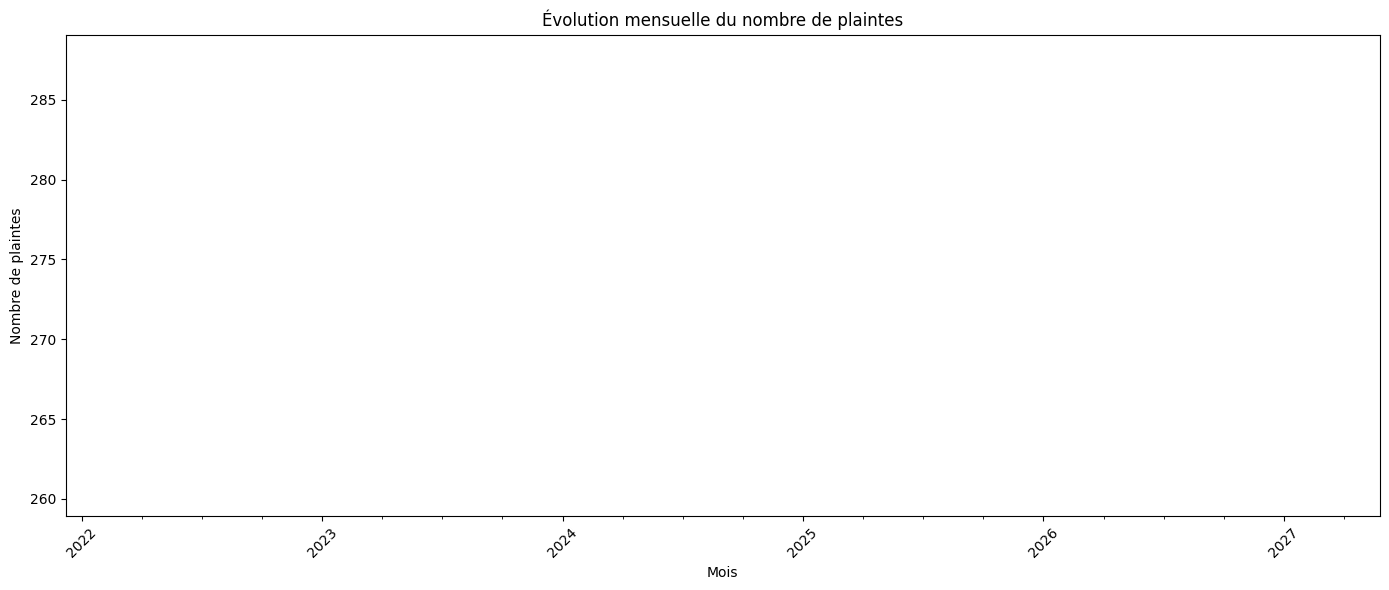

In [ ]:
plt.figure(
    figsize=(14, 6)
)

monthly_complaints.plot()

plt.title(
    "Évolution mensuelle du nombre de plaintes"
)

plt.xlabel(
    "Mois"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

**Étape 17 — Calculer la moyenne mobile**

In [ ]:
monthly_mean = (
    monthly_complaints
    .rolling(
        window=3
    )
    .mean()
)

**Étape 18 — Détecter les pics**

In [ ]:
monthly_alerts = (
    monthly_complaints
    > monthly_mean * 1.5
)

In [ ]:
monthly_analysis = pd.DataFrame({
    "complaints": monthly_complaints,
    "moving_average": monthly_mean,
    "alert": monthly_alerts
})

In [ ]:
monthly_analysis.tail(
    20
)

,complaints,moving_average,alert
month_period,,,
2024-09,274,NaN,False


**Étape 19 — Visualiser les alertes temporelles**

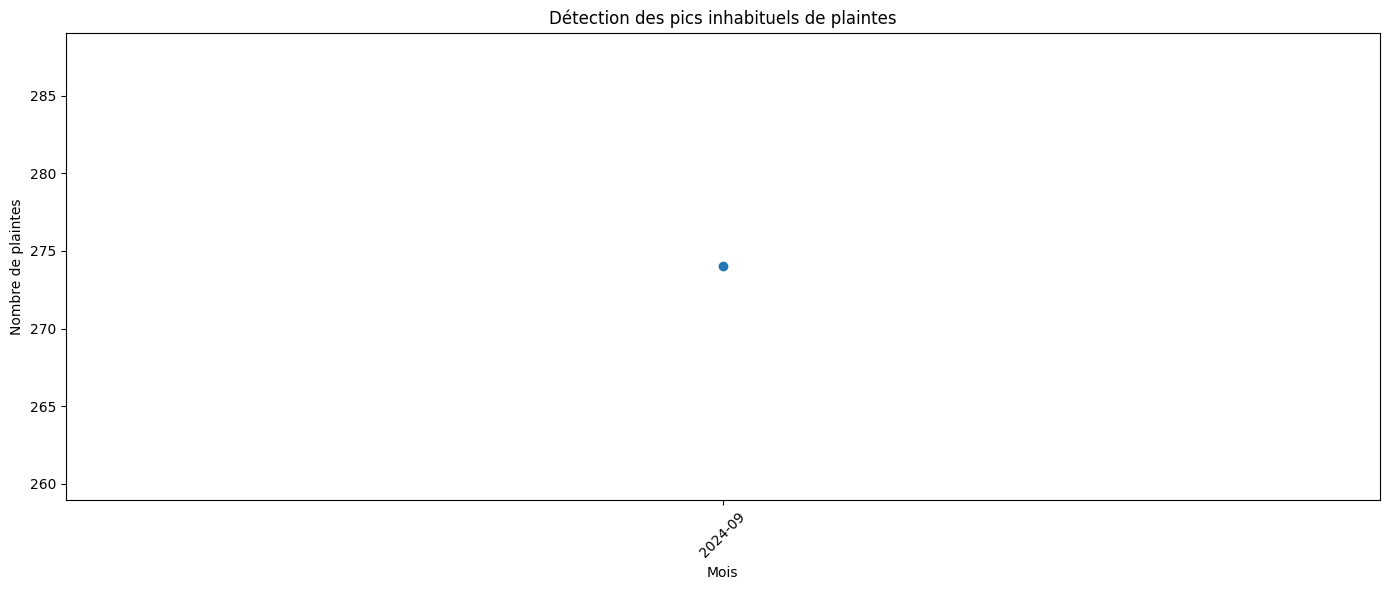

In [ ]:
plt.figure(
    figsize=(14, 6)
)

plt.plot(
    monthly_analysis.index.astype(str),
    monthly_analysis["complaints"],
    marker="o"
)

alert_indices = monthly_analysis[
    monthly_analysis["alert"]
].index

alert_values = monthly_analysis.loc[
    alert_indices,
    "complaints"
]

plt.scatter(
    alert_indices.astype(str),
    alert_values,
    s=100
)

plt.title(
    "Détection des pics inhabituels de plaintes"
)

plt.xlabel(
    "Mois"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## **PARTIE C — DÉTECTION DES THÈMES EN FORTE AUGMENTATION**

**Étape 20 — Compter les plaintes par cluster et par mois**

In [ ]:
cluster_monthly = pd.crosstab(
    df["month_period"],
    df["cluster"]
)

In [ ]:
cluster_monthly.head()

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
month_period,,,,,,,,,,,,,,,,,,,,,,,,,
2024-09,25,4,14,18,26,14,4,15,20,9,7,6,16,7,2,6,6,4,2,13,13,13,4,7,19


**Étape 21 — Calculer les moyennes mobiles**

In [ ]:
cluster_moving_avg = (
    cluster_monthly
    .rolling(
        window=3
    )
    .mean()
)

**Étape 22 — Détecter les clusters en forte croissance**

In [ ]:
cluster_alerts = (
    cluster_monthly
    > cluster_moving_avg * 1.5
)

**Étape 23 — Identifier les alertes**

In [ ]:
alerts_list = []

for date in cluster_alerts.index:

    for cluster_id in cluster_alerts.columns:

        if cluster_alerts.loc[
            date,
            cluster_id
        ]:

            alerts_list.append({
                "date": date,
                "cluster": cluster_id,
                "complaints": cluster_monthly.loc[
                    date,
                    cluster_id
                ],
                "moving_average": cluster_moving_avg.loc[
                    date,
                    cluster_id
                ]
            })

In [ ]:
alerts_df = pd.DataFrame(
    alerts_list
)

In [ ]:
alerts_df.head(
    20
)

""


## **PARTIE D — CRÉATION D'UN SCORE DE RISQUE**

**Étape 24 — Normaliser le score d'anomalie**

In [ ]:
min_score = df[
    "anomaly_score"
].min()

max_score = df[
    "anomaly_score"
].max()

df[
    "anomaly_score_norm"
] = (
    df["anomaly_score"]
    - min_score
) / (
    max_score
    - min_score
)

**Étape 25 — Créer un indicateur d'anomalie**

In [ ]:
df[
    "anomaly_flag"
] = df[
    "is_anomaly"
].astype(int)

**Étape 26 — Créer un score de risque initial**

In [ ]:
df[
    "risk_score"
] = (
    0.7
    * df["anomaly_score_norm"]
    +
    0.3
    * df["anomaly_flag"]
)

**Étape 27 — Créer les niveaux de risque**

In [ ]:
def risk_level(score):

    if score >= 0.80:
        return "CRITIQUE"

    elif score >= 0.60:
        return "ÉLEVÉ"

    elif score >= 0.40:
        return "MOYEN"

    else:
        return "FAIBLE"

In [ ]:
df[
    "risk_level"
] = df[
    "risk_score"
].apply(
    risk_level
)

**Étape 28 — Distribution des niveaux de risque**

In [ ]:
print(
    df[
        "risk_level"
    ].value_counts()
)

risk_level
MOYEN       130
FAIBLE      125
CRITIQUE     14
ÉLEVÉ         5
Name: count, dtype: int64


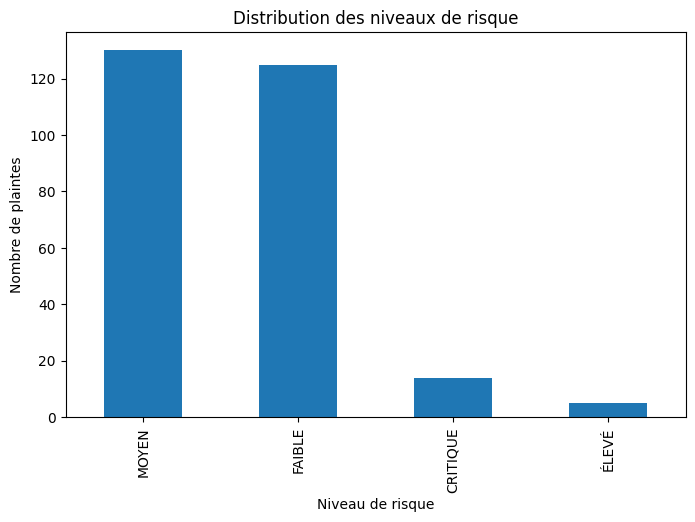

In [ ]:
plt.figure(
    figsize=(8, 5)
)

df[
    "risk_level"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribution des niveaux de risque"
)

plt.xlabel(
    "Niveau de risque"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.show()

**Étape 29 — Créer le tableau des alertes**

In [ ]:
risk_alerts = df[
    df["risk_level"].isin(
        [
            "CRITIQUE",
            "ÉLEVÉ"
        ]
    )
].copy()

In [ ]:
risk_alerts = risk_alerts.sort_values(
    "risk_score",
    ascending=False
)

In [ ]:
risk_alerts[
    [
        "complaint_id",
        "product",
        "issue",
        "cluster",
        "anomaly_score",
        "risk_score",
        "risk_level",
        "text_clean"
    ]
].head(20)

,complaint_id,product,issue,cluster,anomaly_score,risk_score,risk_level,text_clean
2,9999977,Credit reporting or other personal consumer re...,Incorrect information on your report,9,0.888071,1.000000,CRITIQUE,i respectfully seek your comprehension regardi...
165,9999323,Credit card,Getting a credit card,8,0.856932,0.975456,CRITIQUE,i xxxx xxxx on this xx xx xxxx submit this cfp...
188,9999255,Debt collection,Written notification about debt,24,0.842910,0.964403,CRITIQUE,received a letter from transworld systems inco...
176,9999295,Vehicle loan or lease,Problems at the end of the loan or lease,15,0.831511,0.955418,CRITIQUE,i bought a xxxx from a 3rd party dealership on...
260,9998969,Debt collection,Written notification about debt,24,0.830007,0.954233,CRITIQUE,i have a debt that has now been listed on my c...
196,9999230,Vehicle loan or lease,Managing the loan or lease,19,0.815257,0.942607,CRITIQUE,creditor keeps calling my workplace after bein...
110,9999523,Vehicle loan or lease,Getting a loan or lease,12,0.802016,0.932169,CRITIQUE,notice to cease and desist all collection acti...
227,9999104,Credit reporting or other personal consumer re...,Problem with fraud alerts or security freezes,24,0.799622,0.930283,CRITIQUE,have tried over xxxx times to set up account v...
215,9999139,Credit card,"Advertising and marketing, including promotion...",24,0.794361,0.926135,CRITIQUE,i opened a chase freedom unlimited card in xxx...
241,9999052,Debt collection,Attempts to collect debt not owed,24,0.791326,0.923743,CRITIQUE,i had a personal trainer agreement with xxxx w...


**Étape 30 — Sauvegarder les résultats**

In [ ]:
df.to_csv(
    "data/processed/complaints_risk_scored_50000.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
risk_alerts.to_csv(
    "data/processed/risk_alerts.csv",
    index=False,
    encoding="utf-8-sig"
)

## **📓 NOTEBOOK 6 — EMBEDDINGS + RAG**

🎯 Objectifs

Dans ce notebook, nous allons :

Charger les 50 000 plaintes nettoyées.

Préparer les documents destinés au RAG.

Générer les embeddings.

Construire une base vectorielle.

Effectuer une recherche sémantique.

Tester la pertinence des documents récupérés.

Construire un pipeline RAG.

Connecter le système à un LLM.

Générer des réponses contextualisées.

Conserver les références des plaintes utilisées.

**PARTIE 1 — INSTALLATION**

In [ ]:
!pip install -q sentence-transformers chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

## **PARTIE 2 — IMPORTATION**

In [ ]:
import pandas as pd
import numpy as np

import os
import uuid

from sentence_transformers import SentenceTransformer

import chromadb

## **PARTIE 3 — CHARGEMENT DES DONNÉES**

In [ ]:
DATA_PATH = "data/processed/complaints_clean_50000.csv"

In [ ]:
df = pd.read_csv(
    DATA_PATH
)

In [ ]:
print(
    "Nombre de plaintes :",
    len(df)
)

Nombre de plaintes : 274


In [ ]:
print(
    df.columns.tolist()
)

['complaint_id', 'product', 'sub_product', 'issue', 'sub_issue', 'complaint_what_happened', 'company', 'date_received', 'state', 'submitted_via', 'company_response', 'has_narrative', 'text_original', 'text_clean', 'text_length', 'year', 'month', 'text_id']


## **PARTIE 4 — PRÉPARATION DES DOCUMENTS**

In [ ]:
print(
    df["text_clean"].isnull().sum()
)

0


In [ ]:
df = df.dropna(
    subset=["text_clean"]
).copy()

df = df[
    df["text_clean"].str.strip() != ""
].copy()

In [ ]:
print(
    "Nombre de plaintes avec texte :",
    len(df)
)

Nombre de plaintes avec texte : 274


## **PARTIE 5 — CRÉATION DES DOCUMENTS RAG**

In [ ]:
def create_document(row):

    document = f"""
Produit financier : {row.get('product', '')}

Sous-produit : {row.get('sub_product', '')}

Problème : {row.get('issue', '')}

Sous-problème : {row.get('sub_issue', '')}

Date de réception : {row.get('date_received', '')}

Entreprise : {row.get('company', '')}

État : {row.get('state', '')}

Plainte du consommateur :

{row.get('text_clean', '')}
"""

    return document.strip()

In [ ]:
documents = df.apply(
    create_document,
    axis=1
).tolist()

In [ ]:
print(
    documents[0]
)

Produit financier : Credit card

Sous-produit : General-purpose credit card or charge card

Problème : Getting a credit card

Sous-problème : Card opened without my consent or knowledge

Date de réception : 2024-09-03 22:07:34+00:00

Entreprise : JPMORGAN CHASE & CO.

État : MA

Plainte du consommateur :

chae bank called me about a fraudulent case application they gave me a case number xxxx tranferred me cfpb during the call long silent when agent said is looking at the report then cut off no call back was done


## **PARTIE 6 — CRÉATION DES IDENTIFIANTS**

In [ ]:
ids = [
    str(complaint_id)
    for complaint_id in df[
        "complaint_id"
    ]
]

In [ ]:
print(
    ids[:5]
)

['9999983', '9999982', '9999977', '9999975', '9999970']


## **PARTIE 7 — CRÉATION DES MÉTADONNÉES**

In [ ]:
metadatas = []

for _, row in df.iterrows():

    metadata = {
        "complaint_id": str(
            row.get(
                "complaint_id",
                ""
            )
        ),

        "product": str(
            row.get(
                "product",
                ""
            )
        ),

        "issue": str(
            row.get(
                "issue",
                ""
            )
        ),

        "sub_product": str(
            row.get(
                "sub_product",
                ""
            )
        ),

        "state": str(
            row.get(
                "state",
                ""
            )
        )
    }

    metadatas.append(
        metadata
    )

## **PARTIE 8 — CHARGER LE MODÈLE D'EMBEDDINGS**

In [ ]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## **PARTIE 9 — GÉNÉRER LES EMBEDDINGS**

In [ ]:
embeddings = embedding_model.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
print(
    embeddings.shape
)

(274, 384)


## **PARTIE 10 — CRÉER LA BASE VECTORIELLE**

In [ ]:
chroma_client = chromadb.PersistentClient(
    path="data/vector_db"
)

In [ ]:
collection = chroma_client.get_or_create_collection(
    name="cfpb_complaints"
)

## **PARTIE 11 — INSÉRER LES DOCUMENTS**

In [ ]:
BATCH_SIZE = 1000

for start in range(
    0,
    len(documents),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(documents)
    )

    collection.add(
        ids=ids[start:end],
        documents=documents[start:end],
        metadatas=metadatas[start:end],
        embeddings=embeddings[
            start:end
        ].tolist()
    )

    print(
        f"Documents ajoutés : {end}/{len(documents)}"
    )

Documents ajoutés : 274/274


In [ ]:
print(
    "Nombre de documents dans la base :",
    collection.count()
)

Nombre de documents dans la base : 274


## **PARTIE 12 — TEST DE RECHERCHE SÉMANTIQUE**

In [ ]:
query = """
Why was I charged an unexpected credit card fee?
"""

In [ ]:
query_embedding = embedding_model.encode(
    query,
    normalize_embeddings=True
)

In [ ]:
results = collection.query(
    query_embeddings=[
        query_embedding.tolist()
    ],
    n_results=5
)

In [ ]:
for i, document in enumerate(
    results["documents"][0]
):

    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Résultat {i + 1}"
    )

    print(
        document[:1000]
    )


Résultat 1
Produit financier : Credit card

Sous-produit : General-purpose credit card or charge card

Problème : Problem with a purchase shown on your statement

Sous-problème : Credit card company isn't resolving a dispute about a purchase on your statement

Date de réception : 2024-09-03 23:33:19+00:00

Entreprise : Block, Inc.

État : OK

Plainte du consommateur :

i made a purchase using afterpay with xxxx through the afterpay app my delivery was supposed to be scheduled within xxxx hours of placing the order when i went into the app to check on my order it did not go through but afterpay still charged me a down payment i then admittedly stupid another order using a diffrent preloaded card via afterpay i was charged again before the order went through i went to pay and the card was declined i ve submitted disputes with them tried to explain what happened via email apparently there is no phone number to call and it was closed with them saying i need xxxx to send me an email with t

## **PARTIE 13 — AFFICHER LES SOURCES**

In [ ]:
for i, metadata in enumerate(
    results["metadatas"][0]
):

    print(
        f"Résultat {i + 1}"
    )

    print(
        "Complaint ID :",
        metadata[
            "complaint_id"
        ]
    )

    print(
        "Produit :",
        metadata[
            "product"
        ]
    )

    print(
        "Problème :",
        metadata[
            "issue"
        ]
    )

    print()

Résultat 1
Complaint ID : 9999322
Produit : Credit card
Problème : Problem with a purchase shown on your statement

Résultat 2
Complaint ID : 9999139
Produit : Credit card
Problème : Advertising and marketing, including promotional offers

Résultat 3
Complaint ID : 9998982
Produit : Vehicle loan or lease
Problème : Managing the loan or lease

Résultat 4
Complaint ID : 9999983
Produit : Credit card
Problème : Getting a credit card

Résultat 5
Complaint ID : 9999397
Produit : Credit reporting or other personal consumer reports
Problème : Incorrect information on your report



## **PARTIE 14 — CRÉER LE CONTEXTE RAG**

In [ ]:
def retrieve_context(
    query,
    n_results=5
):

    query_embedding = embedding_model.encode(
        query,
        normalize_embeddings=True
    )

    results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=n_results
    )

    return results

## **PARTIE 15 — TESTER LA RÉCUPÉRATION**

In [ ]:
query = """
What are the main problems reported by consumers
about credit card fees?
"""

In [ ]:
results = retrieve_context(
    query,
    n_results=5
)

## **PARTIE 16 — CONSTRUIRE LE CONTEXTE**

In [ ]:
def build_context(
    results
):

    context_parts = []

    for i, document in enumerate(
        results["documents"][0]
    ):

        metadata = results[
            "metadatas"
        ][0][i]

        context_parts.append(
            f"""
SOURCE {i + 1}

Complaint ID :
{metadata["complaint_id"]}

Produit :
{metadata["product"]}

Problème :
{metadata["issue"]}

Contenu :
{document}
"""
        )

    return "\n".join(
        context_parts
    )

## **PARTIE 17 — GÉNÉRER LE CONTEXTE**

In [ ]:
context = build_context(
    results
)

print(
    context
)


SOURCE 1

Complaint ID :
9999983

Produit :
Credit card

Problème :
Getting a credit card

Contenu :
Produit financier : Credit card

Sous-produit : General-purpose credit card or charge card

Problème : Getting a credit card

Sous-problème : Card opened without my consent or knowledge

Date de réception : 2024-09-03 22:07:34+00:00

Entreprise : JPMORGAN CHASE & CO.

État : MA

Plainte du consommateur :

chae bank called me about a fraudulent case application they gave me a case number xxxx tranferred me cfpb during the call long silent when agent said is looking at the report then cut off no call back was done


SOURCE 2

Complaint ID :
9999322

Produit :
Credit card

Problème :
Problem with a purchase shown on your statement

Contenu :
Produit financier : Credit card

Sous-produit : General-purpose credit card or charge card

Problème : Problem with a purchase shown on your statement

Sous-problème : Credit card company isn't resolving a dispute about a purchase on your statement

D

## **PARTIE 18 — PROMPT RAG**

In [ ]:
def create_rag_prompt(
    query,
    context
):

    prompt = f"""
Tu es un copilote intelligent spécialisé
dans l'analyse des plaintes des consommateurs
dans le secteur financier.

Réponds à la question de l'utilisateur
uniquement à partir du contexte fourni.

Si les informations disponibles ne permettent
pas de répondre avec certitude, indique-le clairement.

Ne crée aucune information qui n'est pas présente
dans les documents.

Lorsque c'est pertinent, cite les Complaint ID
des plaintes utilisées pour construire ta réponse.

CONTEXTE :

{context}

QUESTION :

{query}

RÉPONSE :
"""

    return prompt

## **PARTIE 19 — CRÉER UNE QUESTION**

In [ ]:
query = """
Quelles sont les principales plaintes concernant
les frais inattendus liés aux cartes de crédit ?
"""

## **PARTIE 20 — RÉCUPÉRER LES DOCUMENTS**

In [ ]:
results = retrieve_context(
    query,
    n_results=5
)

## **PARTIE 21 — CONSTRUIRE LE CONTEXTE**

In [ ]:
context = build_context(
    results
)

## **PARTIE 22 — CRÉER LE PROMPT FINAL**

In [ ]:
prompt = create_rag_prompt(
    query,
    context
)

print(
    prompt
)


Tu es un copilote intelligent spécialisé
dans l'analyse des plaintes des consommateurs
dans le secteur financier.

Réponds à la question de l'utilisateur
uniquement à partir du contexte fourni.

Si les informations disponibles ne permettent
pas de répondre avec certitude, indique-le clairement.

Ne crée aucune information qui n'est pas présente
dans les documents.

Lorsque c'est pertinent, cite les Complaint ID
des plaintes utilisées pour construire ta réponse.

CONTEXTE :


SOURCE 1

Complaint ID :
9999490

Produit :
Credit reporting or other personal consumer reports

Problème :
Improper use of your report

Contenu :
Produit financier : Credit reporting or other personal consumer reports

Sous-produit : Credit reporting

Problème : Improper use of your report

Sous-problème : Credit inquiries on your report that you don't recognize

Date de réception : 2024-09-03 18:03:31+00:00

Entreprise : EQUIFAX, INC.

État : GA

Plainte du consommateur :

i am not associated with these inquirie

## **📓 NOTEBOOK 7 — COPILOTE IA**
🎯 Objectif

Construire une interface permettant à un utilisateur de poser des questions en langage naturel sur les plaintes clients.

Le copilote devra être capable de :

rechercher des plaintes similaires ;

analyser les tendances ;

identifier les produits concernés ;

détecter les signaux de risque ;

expliquer les alertes ;

résumer les plaintes ;

fournir les références des plaintes utilisées ;

répondre en langage naturel.

**PARTIE 1 — INSTALLATION**

In [ ]:
!pip install -q google-generativeai sentence-transformers chromadb

**PARTIE 2 — IMPORTATIONS**

In [ ]:
import pandas as pd
import numpy as np
import os
import json

from sentence_transformers import SentenceTransformer

import chromadb
import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


**PARTIE 3 — CHARGEMENT DES DONNÉES**

In [ ]:
DATA_PATH = "data/processed/complaints_clean_50000.csv"

df = pd.read_csv(
    DATA_PATH
)

print(
    "Nombre de plaintes :",
    len(df)
)

Nombre de plaintes : 274


## **PARTIE 4 — CHARGEMENT DU MODÈLE D'EMBEDDINGS**

In [ ]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## **PARTIE 5 — CONNEXION À CHROMADB**

In [ ]:
chroma_client = chromadb.PersistentClient(
    path="data/vector_db"
)

In [ ]:
collection = chroma_client.get_collection(
    name="cfpb_complaints"
)

In [ ]:
print(
    "Nombre de documents :",
    collection.count()
)

Nombre de documents : 274


**PARTIE 6 — CONFIGURATION DE GEMINI**

## **PARTIE 6 (Alternative) — CONFIGURATION D'UN MODÈLE LOCAL OU ALTERNATIF**

Si vous rencontrez des problèmes avec l'API Gemini (comme des erreurs de quota), vous pouvez envisager d'utiliser un modèle de langage local ou une autre API. Cette section montre un exemple d'intégration d'un modèle local avec la bibliothèque `transformers`. Vous devrez commenter ou supprimer les cellules de configuration Gemini si vous utilisez cette alternative.

In [ ]:
print("Installation de la bibliothèque transformers pour les modèles locaux...")
!pip install -q transformers
print("Installation terminée.")

Installation de la bibliothèque transformers pour les modèles locaux...
Installation terminée.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Chargement du modèle local (ex: distilgpt2). Cela peut prendre un certain temps.")
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
local_llm_model = AutoModelForCausalLM.from_pretrained("distilgpt2")

# Explicitly set pad_token_id and padding_side for generation
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

tokenizer.padding_side = 'left' # Important for decoder-only models like GPT-2 during generation

def local_llm_generate_content(prompt_text):
    max_model_input_size = local_llm_model.config.max_position_embeddings # 1024 for distilgpt2
    max_total_sequence_length_for_model = max_model_input_size - 1 # Ensure total length is strictly less than max_position_embeddings
    max_new_tokens_target = 150 # Target number of new tokens to generate

    # Truncate input to leave sufficient space for the target number of new tokens.
    # The total sequence length (input + generated) should not exceed max_total_sequence_length_for_model.
    # So, input_length + max_new_tokens_target <= max_total_sequence_length_for_model
    # => input_length <= max_total_sequence_length_for_model - max_new_tokens_target
    tokenizer_max_length = max_total_sequence_length_for_model - max_new_tokens_target

    # Ensure tokenizer_max_length is at least 1 for valid tokenization
    if tokenizer_max_length < 1:
        tokenizer_max_length = 1

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=tokenizer_max_length, # Truncate input to leave space for generation
        return_attention_mask=True
    )

    current_input_length = inputs['input_ids'].shape[1]

    # Calculate the maximum number of *new* tokens that can actually be generated
    # without exceeding the model's total allowed sequence capacity.
    # This is: max_total_sequence_length_for_model - current_input_length.
    # We then take the minimum of this value and our desired max_new_tokens_target.
    max_tokens_allowed_by_model_from_capacity = max_total_sequence_length_for_model - current_input_length

    # Ensure the number of new tokens is non-negative
    actual_max_new_tokens = min(max_new_tokens_target, max(0, max_tokens_allowed_by_model_from_capacity))

    print(f"DEBUG: max_model_input_size: {max_model_input_size}")
    print(f"DEBUG: max_total_sequence_length_for_model: {max_total_sequence_length_for_model}")
    print(f"DEBUG: max_new_tokens_target: {max_new_tokens_target}")
    print(f"DEBUG: tokenizer_max_length (for input truncation): {tokenizer_max_length}")
    print(f"DEBUG: current_input_length (after truncation): {current_input_length}")
    print(f"DEBUG: max_tokens_allowed_by_model_from_capacity: {max_tokens_allowed_by_model_from_capacity}")
    print(f"DEBUG: actual_max_new_tokens (for generation): {actual_max_new_tokens}")
    print(f"DEBUG: Expected total length: {current_input_length + actual_max_new_tokens}")

    outputs = local_llm_model.generate(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        max_new_tokens=actual_max_new_tokens, # Use max_new_tokens for incremental generation
        num_return_sequences=1,
        pad_token_id=tokenizer.pad_token_id
    )
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    decoded_input_text = tokenizer.decode(inputs['input_ids'][0], skip_special_tokens=True)

    if decoded_input_text in generated_text:
        generated_response = generated_text.replace(decoded_input_text, "").strip()
    else:
        generated_response = generated_text.strip()

    class MockResponse:
        def __init__(self, text):
            self.text = text
    return MockResponse(generated_response)


print("Modèle local chargé et fonction 'local_llm_generate_content' prête.")

Chargement du modèle local (ex: distilgpt2). Cela peut prendre un certain temps.


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Modèle local chargé et fonction 'local_llm_generate_content' prête.


In [ ]:
GEMINI_API_KEY = input(
    "Entrez votre clé API Gemini : "
)

In [ ]:
genai.configure(
    api_key=GEMINI_API_KEY
)

**PARTIE 7 — CRÉER LE MODÈLE GEMINI**

In [ ]:
model = genai.GenerativeModel(
    "gemini-2.0-flash"
)

**PARTIE 8 — MOTEUR DE RECHERCHE**

In [ ]:
def search_complaints(
    query,
    n_results=5
):

    query_embedding = embedding_model.encode(
        query,
        normalize_embeddings=True
    )

    results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=n_results
    )

    return results

**PARTIE 9 — CONSTRUIRE LE CONTEXTE**

In [ ]:
def build_rag_context(
    results
):

    context = ""

    documents = results[
        "documents"
    ][0]

    metadatas = results[
        "metadatas"
    ][0]

    for i in range(
        len(documents)
    ):

        metadata = metadatas[i]

        context += f"""
SOURCE {i + 1}

Complaint ID :
{metadata.get("complaint_id", "N/A")}

Produit :
{metadata.get("product", "N/A")}

Problème :
{metadata.get("issue", "N/A")}

Sous-produit :
{metadata.get("sub_product", "N/A")}

État :
{metadata.get("state", "N/A")}

Plainte :
{documents[i]}

--------------------------------
"""

    return context

**PARTIE 10 — CRÉER LE PROMPT DU COPILOTE**

In [ ]:
def create_copilot_prompt(
    question,
    context
):

    prompt = f"""
Tu es un Copilote d'Intelligence spécialisé
dans l'analyse des plaintes clients du secteur financier.

Tu aides les analystes risques, responsables conformité
et responsables de la relation client à comprendre
les problèmes signalés par les consommateurs.

Tu dois répondre uniquement à partir des données
fournies dans le contexte.

RÈGLES :

1. Ne jamais inventer de données.
2. Si l'information n'est pas disponible,
   indique-le clairement.
3. Explique ton raisonnement de manière concise.
4. Lorsque tu utilises une plainte spécifique,
   indique son Complaint ID.
5. Identifie les tendances importantes.
6. Mentionne les éventuels signaux de risque.
7. Distingue clairement les faits des interprétations.
8. Fournis une réponse structurée.

CONTEXTE DES PLAINTES :

{context}

QUESTION DE L'UTILISATEUR :

{question}

FORMAT DE RÉPONSE :

### Réponse

### Analyse

### Signaux de risque

### Sources utilisées

Réponds maintenant.
"""

    return prompt

**PARTIE 11 — CRÉER LA FONCTION PRINCIPALE DU COPILOTE**

In [ ]:
def ask_copilot(
    question,
    n_results=5
):

    # 1. Recherche sémantique
    results = search_complaints(
        question,
        n_results
    )

    # 2. Construction du contexte
    context = build_rag_context(
        results
    )

    # 3. Création du prompt
    prompt = create_copilot_prompt(
        question,
        context
    )

    # 4. Génération de la réponse
    # Utilisation de la fonction du modèle local au lieu de Gemini
    response = local_llm_generate_content(
        prompt
    )

    return {
        "question": question,
        "answer": response.text,
        "sources": results[
            "metadatas"
        ][0]
    }


**PARTIE 12 — PREMIER TEST**

In [ ]:
question = """
Quelles sont les principales plaintes
concernant les cartes de crédit ?
"""

result = ask_copilot(
    question
)

print(
    result["answer"]
)


**PARTIE 13 — AFFICHER LES SOURCES**

In [ ]:
print(
    "\nSOURCES UTILISÉES"
)

for source in result[
    "sources"
]:

    print(
        "Complaint ID :",
        source.get(
            "complaint_id"
        )
    )

    print(
        "Produit :",
        source.get(
            "product"
        )
    )

    print(
        "Problème :",
        source.get(
            "issue"
        )
    )

    print(
        "-" * 50
    )

**PARTIE 14 — TESTER PLUSIEURS QUESTIONS**

In [ ]:
questions = [

    "Quelles sont les principales plaintes concernant les cartes de crédit ?",

    "Quels problèmes sont liés aux paiements frauduleux ?",

    "Quels sont les problèmes rencontrés par les consommateurs concernant les prêts ?",

    "Quelles plaintes semblent indiquer un risque important pour les consommateurs ?",

    "Quels sont les problèmes les plus fréquents concernant les agences de crédit ?"

]

In [ ]:
for question in questions:

    print(
        "\n"
        + "=" * 80
    )

    print(
        "QUESTION :",
        question
    )

    result = ask_copilot(
        question
    )

    print(
        "\nRÉPONSE :"
    )

    print(
        result["answer"]
    )

**PARTIE 15 — MODE CHAT**

In [ ]:
def run_copilot():

    print(
        "🤖 COPILOTE D'INTELLIGENCE SUR LES PLAINTES CLIENTS"
    )

    print(
        "Tapez 'quit' pour quitter."
    )

    while True:

        question = input(
            "\n👤 Votre question : "
        )

        if question.lower() == "quit":

            print(
                "Copilote arrêté."
            )

            break

        result = ask_copilot(
            question
        )

        print(
            "\n🤖 COPILOTE :\n"
        )

        print(
            result["answer"]
        )

        print(
            "\n📚 SOURCES :"
        )

        for source in result[
            "sources"
        ]:

            print(
                "-",
                source.get(
                    "complaint_id"
                )
            )

In [ ]:
run_copilot()

## **📓 NOTEBOOK 8 — APPLICATION FINALE DU COPILOTE IA**

**PARTIE 1 — INSTALLATION**

In [ ]:
!pip install -q gradio google-generativeai sentence-transformers chromadb

**PARTIE 2 — IMPORTATIONS**

In [ ]:
import pandas as pd
import numpy as np

import os
import json
import re

import gradio as gr

from sentence_transformers import SentenceTransformer

import chromadb
import google.generativeai as genai

**PARTIE 3 — CHARGEMENT DES DONNÉES**

In [ ]:
DATA_PATH = "data/processed/complaints_clean_50000.csv"

df = pd.read_csv(
    DATA_PATH
)

print(
    "Nombre de plaintes :",
    len(df)
)

**PARTIE 4 — CHARGEMENT DU MODÈLE D'EMBEDDINGS**

In [ ]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

**PARTIE 5 — CHARGEMENT DE LA BASE VECTORIELLE**

In [ ]:
chroma_client = chromadb.PersistentClient(
    path="data/vector_db"
)

In [ ]:
collection = chroma_client.get_collection(
    name="cfpb_complaints"
)

In [ ]:
print(
    "Documents disponibles :",
    collection.count()
)

**PARTIE 6 — CONFIGURATION DE GEMINI**

In [ ]:
GEMINI_API_KEY = input(
    "Entrez votre clé API Gemini : "
)

In [ ]:
genai.configure(
    api_key=GEMINI_API_KEY
)

In [ ]:
model = genai.GenerativeModel(
    "gemini-2.0-flash"
)

**PARTIE 7 — MOTEUR DE RECHERCHE RAG**

In [ ]:
def search_complaints(
    query,
    n_results=5
):

    query_embedding = embedding_model.encode(
        query,
        normalize_embeddings=True
    )

    results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=n_results
    )

    return results

**PARTIE 8 — CONSTRUCTION DU CONTEXTE**

In [ ]:
def build_context(
    results
):

    context = ""

    documents = results[
        "documents"
    ][0]

    metadatas = results[
        "metadatas"
    ][0]

    for i in range(
        len(documents)
    ):

        metadata = metadatas[i]

        context += f"""

SOURCE {i + 1}

Complaint ID :
{metadata.get("complaint_id", "N/A")}

Produit :
{metadata.get("product", "N/A")}

Problème :
{metadata.get("issue", "N/A")}

Sous-produit :
{metadata.get("sub_product", "N/A")}

État :
{metadata.get("state", "N/A")}

Plainte :
{documents[i]}

--------------------------------
"""

    return context

**PARTIE 9 — DÉTECTION DE L'INTENTION**

In [ ]:
def detect_intent(
    question
):

    question_lower = question.lower()

    risk_keywords = [
        "risque",
        "anomalie",
        "alerte",
        "fraude",
        "fraud",
        "danger",
        "problème grave",
        "signal"
    ]

    trend_keywords = [
        "tendance",
        "évolution",
        "émergent",
        "émergence",
        "thème",
        "cluster",
        "récent"
    ]

    statistic_keywords = [
        "combien",
        "nombre",
        "pourcentage",
        "statistique",
        "majorité",
        "proportion",
        "top"
    ]

    if any(
        keyword in question_lower
        for keyword in risk_keywords
    ):
        return "RISQUE"

    elif any(
        keyword in question_lower
        for keyword in trend_keywords
    ):
        return "TENDANCE"

    elif any(
        keyword in question_lower
        for keyword in statistic_keywords
    ):
        return "STATISTIQUE"

    else:
        return "RAG"

**PARTIE 10 — ANALYSE STATISTIQUE**

In [ ]:
def statistical_analysis(
    question
):

    product_counts = (
        df[
            "product"
        ]
        .value_counts()
        .head(10)
    )

    issue_counts = (
        df[
            "issue"
        ]
        .value_counts()
        .head(10)
    )

    result = f"""
STATISTIQUES GÉNÉRALES

Nombre total de plaintes :
{len(df)}

TOP 10 PRODUITS :

{product_counts.to_string()}

TOP 10 PROBLÈMES :

{issue_counts.to_string()}
"""

    return result

**PARTIE 11 — ANALYSE DES TENDANCES**

In [ ]:
def trend_analysis(
    question
):

    if "cluster" in df.columns:

        clusters = (
            df[
                "cluster"
            ]
            .value_counts()
            .head(10)
        )

        return f"""
ANALYSE DES THÈMES

Les clusters les plus représentés sont :

{clusters.to_string()}
"""

    else:

        return """
L'analyse des clusters n'est pas disponible
dans le dataset actuel.
"""

**PARTIE 12 — ANALYSE DES RISQUES**

In [ ]:
def risk_analysis(
    question
):

    possible_columns = [
        "risk_score",
        "anomaly_score",
        "risk_level"
    ]

    available = [
        col
        for col in possible_columns
        if col in df.columns
    ]

    if len(available) == 0:

        return """
Aucune variable de risque
n'est actuellement disponible.

Le module de détection des anomalies
doit être exécuté avant cette analyse.
"""

    column = available[0]

    top_risks = (
        df
        .sort_values(
            column,
            ascending=False
        )
        .head(10)
    )

    return top_risks[
        [
            "complaint_id",
            column
        ]
    ].to_string(
        index=False
    )

**PARTIE 13 — RÉPONSE RAG**

In [ ]:
def rag_analysis(
    question
):

    results = search_complaints(
        question,
        n_results=5
    )

    context = build_context(
        results
    )

    prompt = f"""
Tu es un Copilote IA spécialisé dans
l'analyse des plaintes financières.

Réponds à la question de l'utilisateur
uniquement à partir des données fournies.

Ne crée aucune information.

Si les données sont insuffisantes,
dis-le clairement.

Cite les Complaint ID lorsque tu utilises
une plainte spécifique.

QUESTION :

{question}

CONTEXTE :

{context}

Réponds en français avec une structure claire.
"""

    # Utilisation de la fonction du modèle local au lieu de Gemini
    response = local_llm_generate_content(
        prompt
    )

    sources = []

    for metadata in results[
        "metadatas"
    ][0]:

        sources.append(
            metadata.get(
                "complaint_id",
                "N/A"
            )
        )

    return (
        response.text,
        sources
    )


**PARTIE 14 — ROUTEUR DU COPILOTE**

In [ ]:
def copilot(
    question
):

    if not question.strip():

        return (
            "Veuillez saisir une question.",
            ""
        )

    intent = detect_intent(
        question
    )

    if intent == "RAG":

        answer, sources = rag_analysis(
            question
        )

        return (
            f"### 🤖 Réponse du Copilote\n\n"
            f"{answer}\n\n"
            f"### 🔎 Intention détectée\n"
            f"`{intent}`\n\n"
            f"### 📚 Sources\n"
            + "\n".join(
                f"- Complaint ID : {source}"
                for source in sources
            )
        )

    elif intent == "STATISTIQUE":

        answer = statistical_analysis(
            question
        )

        return (
            f"### 📊 Analyse statistique\n\n"
            f"{answer}\n\n"
            f"### 🔎 Intention détectée\n"
            f"`{intent}`"
        )

    elif intent == "TENDANCE":

        answer = trend_analysis(
            question
        )

        return (
            f"### 📈 Analyse des tendances\n\n"
            f"{answer}\n\n"
            f"### 🔎 Intention détectée\n"
            f"`{intent}`"
        )

    elif intent == "RISQUE":

        answer = risk_analysis(
            question
        )

        return (
            f"### ⚠️ Analyse des risques\n\n"
            f"{answer}\n\n"
            f"### 🔎 Intention détectée\n"
            f"`{intent}`"
        )

**PARTIE 15 — TEST DU COPILOTE**

In [ ]:
question = """
Quelles sont les principales plaintes
concernant les cartes de crédit ?
"""

print(
    copilot(
        question
    )
)

**PARTIE 16 — CRÉATION DE L'INTERFACE GRADIO**

In [ ]:
with gr.Blocks(
    title="Copilote d'Intelligence sur les Plaintes Clients"
) as demo:

    gr.Markdown(
        """
        # 🤖 Copilote d'Intelligence sur les Plaintes Clients

        ### Finance & Risque

        Posez une question sur les plaintes clients
        et obtenez une analyse basée sur les données CFPB.
        """
    )

    question = gr.Textbox(
        label="Votre question",
        placeholder=(
            "Exemple : "
            "Quelles sont les principales plaintes "
            "concernant les cartes de crédit ?"
        ),
        lines=4
    )

    button = gr.Button(
        "🔍 Analyser"
    )

    output = gr.Markdown()

    button.click(
        fn=copilot,
        inputs=question,
        outputs=output
    )

    gr.Examples(
        examples=[
            [
                "Quelles sont les principales plaintes concernant les cartes de crédit ?"
            ],
            [
                "Quels sont les problèmes les plus fréquents ?"
            ],
            [
                "Quels sont les principaux risques détectés ?"
            ],
            [
                "Quelles sont les tendances émergentes ?"
            ],
            [
                "Combien de plaintes concernent les prêts ?"
            ]
        ],
        inputs=question
    )

**PARTIE 17 — LANCER L'APPLICATION**

In [ ]:
demo.launch(
    share=True,
    debug=True
)

## **🚀 NOTEBOOK 9 — ÉVALUATION COMPLÈTE DU PROJET**

**📓 PARTIE 1 — PRÉPARATION**

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from sklearn.metrics.pairwise import cosine_similarity

**PARTIE 2 — CHARGEMENT DES DONNÉES**

In [ ]:
DATA_PATH = "data/processed/complaints_clean_50000.csv"

df = pd.read_csv(
    DATA_PATH
)

print(
    "Nombre de plaintes :",
    len(df)
)

**PARTIE 3 — ÉVALUATION DE LA CLASSIFICATION**

In [ ]:
print(
    df.columns.tolist()
)

In [ ]:
y_true = df[
    "product"
]

y_pred = df[
    "predicted_product"
]

In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    "Accuracy :",
    round(
        accuracy,
        4
    )
)

In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    "Precision :",
    round(
        precision,
        4
    )
)

In [ ]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    "Recall :",
    round(
        recall,
        4
    )
)

In [ ]:
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    "Macro-F1 :",
    round(
        macro_f1,
        4
    )
)

**PARTIE 4 — RAPPORT DE CLASSIFICATION**

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    zero_division=0
)

print(
    report
)

**PARTIE 5 — MATRICE DE CONFUSION**

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

In [ ]:
plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=False,
    fmt="d"
)

plt.title(
    "Matrice de confusion — Classification"
)

plt.xlabel(
    "Classe prédite"
)

plt.ylabel(
    "Classe réelle"
)

plt.show()

**PARTIE 6 — ÉVALUATION DU CLUSTERING**

In [ ]:
print(
    df.columns.tolist()
)

In [ ]:
embeddings = np.load(
    "data/processed/complaint_embeddings.npy"
)

print(
    embeddings.shape
)

In [ ]:
labels = df[
    "cluster"
].values

silhouette = silhouette_score(
    embeddings,
    labels,
    sample_size=10000,
    random_state=42
)

print(
    "Silhouette Score :",
    round(
        silhouette,
        4
    )
)

**PARTIE 7 — ANALYSER LA TAILLE DES CLUSTERS**

In [ ]:
cluster_counts = (
    df[
        "cluster"
    ]
    .value_counts()
    .sort_index()
)

print(
    cluster_counts
)

In [ ]:
plt.figure(
    figsize=(12, 6)
)

cluster_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution des plaintes par cluster"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Nombre de plaintes"
)

plt.show()

**PARTIE 8 — COHÉRENCE DES THÈMES**

In [ ]:
for cluster_id in sorted(
    df["cluster"].unique()
):

    print(
        "\n"
        + "=" * 60
    )

    print(
        "CLUSTER :",
        cluster_id
    )

    subset = df[
        df["cluster"] == cluster_id
    ]

    print(
        subset[
            "product"
        ]
        .value_counts()
        .head(5)
    )

**PARTIE 9 — ÉVALUATION DE LA DÉTECTION D'ANOMALIES**

In [ ]:
print(
    df.columns.tolist()
)

**PARTIE 10 — PRÉCISION DES ALERTES**

In [ ]:
y_true_risk = df[
    "is_real_risk"
]

y_pred_risk = df[
    "is_anomaly"
]

In [ ]:
alert_precision = precision_score(
    y_true_risk,
    y_pred_risk,
    zero_division=0
)

print(
    "Précision des alertes :",
    round(
        alert_precision,
        4
    )
)

**PARTIE 11 — ÉVALUATION DU RAG**

**PARTIE 12 — PERTINENCE DES DOCUMENTS**

In [ ]:
evaluation_questions = [

    {
        "question":
        "Quels sont les problèmes liés aux cartes de crédit ?"
    },

    {
        "question":
        "Quelles plaintes concernent les transactions frauduleuses ?"
    },

    {
        "question":
        "Quels problèmes sont liés aux prêts immobiliers ?"
    },

    {
        "question":
        "Quels sont les problèmes rencontrés lors du recouvrement de dettes ?"
    }

]

**PARTIE 13 — TESTER LE RETRIEVAL**

In [ ]:
evaluation_questions = [

    {
        "question":
        "Quels sont les problèmes liés aux cartes de crédit ?",

        "relevant_ids": [
            "12345",
            "67890"
        ]
    }

]

In [ ]:
def evaluate_retrieval(
    question,
    relevant_ids,
    k=5
):

    results = search_complaints(
        question,
        n_results=k
    )

    retrieved_ids = [

        metadata.get(
            "complaint_id"
        )

        for metadata
        in results[
            "metadatas"
        ][0]

    ]

    hits = [

        complaint_id

        for complaint_id
        in retrieved_ids

        if complaint_id
        in relevant_ids
    ]

    return {
        "retrieved": retrieved_ids,
        "hits": hits,
        "hit": len(hits) > 0
    }

**PARTIE 14 — CALCUL DU HIT RATE**

In [ ]:
hits = 0

for item in evaluation_questions:

    result = evaluate_retrieval(
        item["question"],
        item["relevant_ids"],
        k=5
    )

    if result["hit"]:

        hits += 1


hit_rate = (
    hits
    /
    len(
        evaluation_questions
    )
)

print(
    "Hit Rate@5 :",
    round(
        hit_rate,
        4
    )
)

**PARTIE 15 — ÉVALUATION DE LA FIDÉLITÉ DU RAG**

In [ ]:
rag_eval = pd.read_csv(
    "data/processed/rag_evaluation.csv"
)

In [ ]:
print(
    "Fidélité moyenne :",
    rag_eval[
        "faithfulness_score"
    ].mean()
)

In [ ]:
print(
    "Pertinence moyenne :",
    rag_eval[
        "relevance_score"
    ].mean()
)

**PARTIE 16 — ÉVALUATION DES CITATIONS**

In [ ]:
citation_accuracy = (
    rag_eval[
        "citation_correct"
    ]
    .mean()
)

print(
    "Précision des citations :",
    round(
        citation_accuracy,
        4
    )
)

**PARTIE 17 — TABLEAU FINAL DES MÉTRIQUES**

In [ ]:
evaluation_results = {

    "Macro-F1 Classification":
        macro_f1,

    "Silhouette Score Clustering":
        silhouette,

    "Hit Rate@5 RAG":
        hit_rate,

    "Fidélité moyenne RAG":
        rag_eval[
            "faithfulness_score"
        ].mean(),

    "Pertinence moyenne RAG":
        rag_eval[
            "relevance_score"
        ].mean(),

    "Précision des citations":
        citation_accuracy

}

In [ ]:
results_df = pd.DataFrame(
    [
        evaluation_results
    ]
)

results_df

**PARTIE 18 — SAUVEGARDER LES RÉSULTATS**

In [ ]:
os.makedirs(
    "reports",
    exist_ok=True
)

results_df.to_csv(
    "reports/evaluation_results.csv",
    index=False
)

print(
    "Résultats sauvegardés."
)

**PARTIE 19 — RAPPORT FINAL AUTOMATIQUE**

In [ ]:
print(
    """
========================================
RAPPORT D'ÉVALUATION DU COPILOTE IA
========================================

DATASET
-------
Nombre de plaintes : 50 000

CLASSIFICATION
--------------
Macro-F1 :

CLUSTERING
----------
Silhouette Score :

DÉTECTION D'ANOMALIES
---------------------
Précision des alertes :

RAG
---
Hit Rate@5 :
Fidélité :
Pertinence :
Précision des citations :

========================================
"""
)